# Business Problem
This project aims to analyze the tourist rental market in Barcelona using public data from InsideAirbnb. Using a statistical and predictive approach, linear regression and Random Forest models were developed to identify the most relevant variables influencing the estimated price of accommodations.

The project content is structured as a Python script, which includes data cleaning, exploratory analysis, model generation, and results evaluation. This analysis allows key insights to be extracted about the impact of characteristics such as the number of rooms, location, reputation, and presence of amenities on property values.

The main use of this notebook is to serve as a technical basis for building interactive dashboards in Power BI or Looker Studio, where the model results are visualized in a clear and accessible way to facilitate strategic decision-making.

Thanks to the developed predictive models, it is possible to:

* Estimate property prices based on their attributes

* Detect which variables have the greatest weight in the valuation

* Simulate improvement scenarios (activation of amenities, increased reputation, etc.)

* Support decisions on investment, supply optimization, and market segmentation

This approach combines the power of statistical analysis with the flexibility of visualization, generating a robust tool for understanding market behavior and improving the management of tourist properties in Barcelona.

In [ ]:
import pandas as pd


listings = pd.read_csv("listings.csv.gz")


print(listings.head())


      id                         listing_url       scrape_id last_scraped  \
0  18674  https://www.airbnb.com/rooms/18674  20250305023237   2025-03-06   
1  23197  https://www.airbnb.com/rooms/23197  20250305023237   2025-03-07   
2  32711  https://www.airbnb.com/rooms/32711  20250305023237   2025-03-06   
3  34241  https://www.airbnb.com/rooms/34241  20250305023237   2025-03-05   
4  34981  https://www.airbnb.com/rooms/34981  20250305023237   2025-03-05   

        source                                               name  \
0  city scrape    Huge flat for 8 people close to Sagrada Familia   
1  city scrape  Forum CCIB DeLuxe, Spacious, Large Balcony, relax   
2  city scrape                   Sagrada Familia area - Còrsega 1   
3  city scrape   Stylish Top Floor Apartment - Ramblas Plaza Real   
4  city scrape               VIDRE HOME PLAZA REAL on LAS RAMBLAS   

                                         description  \
0  110m2 apartment to rent in Barcelona. Located ...   
1  Beautif

In [ ]:
#Que columnas tiene
print("Columnas del DataFrame:\n")
for i, col in enumerate(listings.columns, start=1):
    print(f"{i:02d}. {col}")


Columnas del DataFrame:

01. id
02. listing_url
03. scrape_id
04. last_scraped
05. source
06. name
07. description
08. neighborhood_overview
09. picture_url
10. host_id
11. host_url
12. host_name
13. host_since
14. host_location
15. host_about
16. host_response_time
17. host_response_rate
18. host_acceptance_rate
19. host_is_superhost
20. host_thumbnail_url
21. host_picture_url
22. host_neighbourhood
23. host_listings_count
24. host_total_listings_count
25. host_verifications
26. host_has_profile_pic
27. host_identity_verified
28. neighbourhood
29. neighbourhood_cleansed
30. neighbourhood_group_cleansed
31. latitude
32. longitude
33. property_type
34. room_type
35. accommodates
36. bathrooms
37. bathrooms_text
38. bedrooms
39. beds
40. amenities
41. price
42. minimum_nights
43. maximum_nights
44. minimum_minimum_nights
45. maximum_minimum_nights
46. minimum_maximum_nights
47. maximum_maximum_nights
48. minimum_nights_avg_ntm
49. maximum_nights_avg_ntm
50. calendar_updated
51. has_avail

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Calcular nulos por columna
nulos = listings.isnull().sum()
total_filas = len(listings)

# Filtrar columnas con al menos un nulo
columnas_con_nulos = nulos[nulos > 0]

# Calcular porcentaje
porcentaje_nulos = (columnas_con_nulos / total_filas) * 100

# Combinar en un DataFrame para mejor visualización
resultado = pd.DataFrame({
    "Nulos": columnas_con_nulos,
    "Porcentaje (%)": porcentaje_nulos.round(2)
}).sort_values(by="Porcentaje (%)", ascending=False)

# Mostrar resultados
print("📊 Columnas con datos nulos (en número y porcentaje):")
print(resultado)


📊 Columnas con datos nulos (en número y porcentaje):
                             Nulos  Porcentaje (%)
calendar_updated             19422          100.00
host_neighbourhood            9921           51.08
neighborhood_overview         9847           50.70
neighbourhood                 9847           50.70
host_about                    7214           37.14
license                       6222           32.04
review_scores_checkin         4913           25.30
review_scores_cleanliness     4911           25.29
review_scores_accuracy        4912           25.29
review_scores_value           4912           25.29
review_scores_location        4912           25.29
review_scores_rating          4909           25.28
reviews_per_month             4909           25.28
review_scores_communication   4910           25.28
last_review                   4909           25.28
first_review                  4909           25.28
host_location                 4503           23.19
beds                         

In [ ]:
#Analisis exploratorio de las variables y limpieza

In [ ]:
#Limpiar price
import numpy as np

# Paso 1: Convertir a string y eliminar símbolos no numéricos
listings["price"] = listings["price"].astype(str).str.replace(r"[^0-9.]", "", regex=True)

# Paso 2: Reemplazar cadenas vacías con np.nan
listings["price"] = listings["price"].replace("", np.nan)

# Paso 3: Convertir a float
listings["price"] = listings["price"].astype(float)


In [ ]:
#Modelo prueba con todas las variables numericas

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Copia del DataFrame original
df = listings.copy()


# Filtrar solo columnas numéricas del DataFrame original
df = listings.select_dtypes(include=["int64", "float64"])

# Eliminar filas con NaN en la variable objetivo
df = df[df["review_scores_rating"].notnull()]

# Separar variables predictoras y objetivo
X = df.drop(columns="review_scores_rating")
y = df["review_scores_rating"]

# Eliminar filas con NaNs en X y alinear y
umbral = 0.5
X = X.loc[:, X.isnull().mean() < umbral]
X = X.dropna()
y = y.loc[X.index]



In [ ]:
!pip install --upgrade scikit-learn


🔹 R² score: 0.850
🔹 RMSE: 0.19


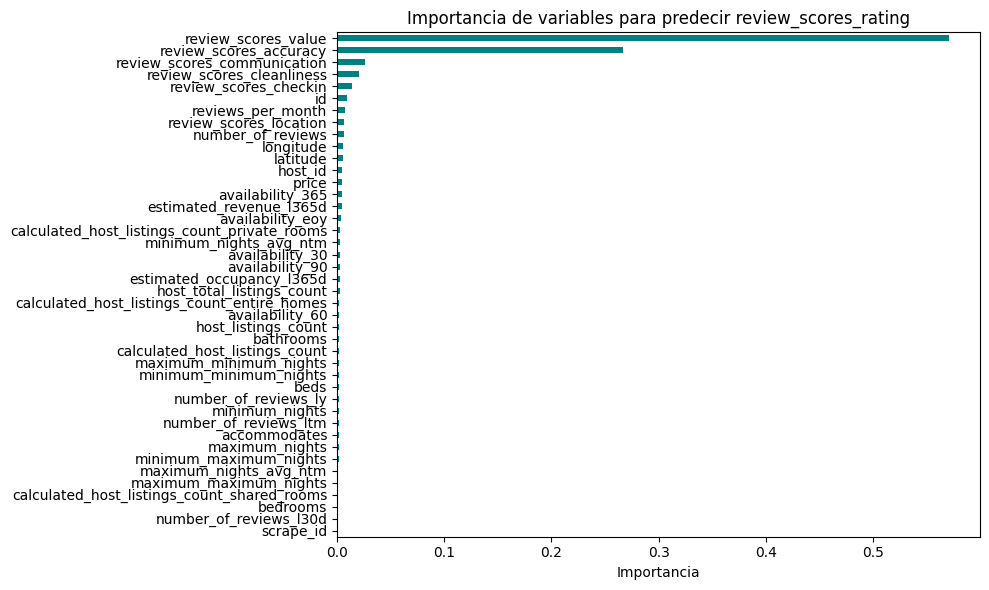

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

# ================================
# DIVISIÓN EN ENTRENAMIENTO Y PRUEBA
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ================================
# ENTRENAMIENTO DEL MODELO
# ================================
modelo = RandomForestRegressor(random_state=42)
modelo.fit(X_train, y_train)

# ================================
# EVALUACIÓN DEL MODELO
# ================================
y_pred = modelo.predict(X_test)

print(f"🔹 R² score: {r2_score(y_test, y_pred):.3f}")
print(f"🔹 RMSE: {mean_squared_error(y_test, y_pred)**0.5:.2f}")

# ================================
# IMPORTANCIA DE VARIABLES
# ================================
importancia = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancia.plot(kind='barh', color='teal')
plt.title("Importancia de variables para predecir review_scores_rating")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

In [ ]:
# Calcular correlación de todas las variables con review_scores_rating
correlaciones = df.corr()["review_scores_rating"].drop("review_scores_rating")
correlaciones_ordenadas = correlaciones.sort_values(ascending=False)


/tmp/ipython-input-13-3923472310.py:13: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


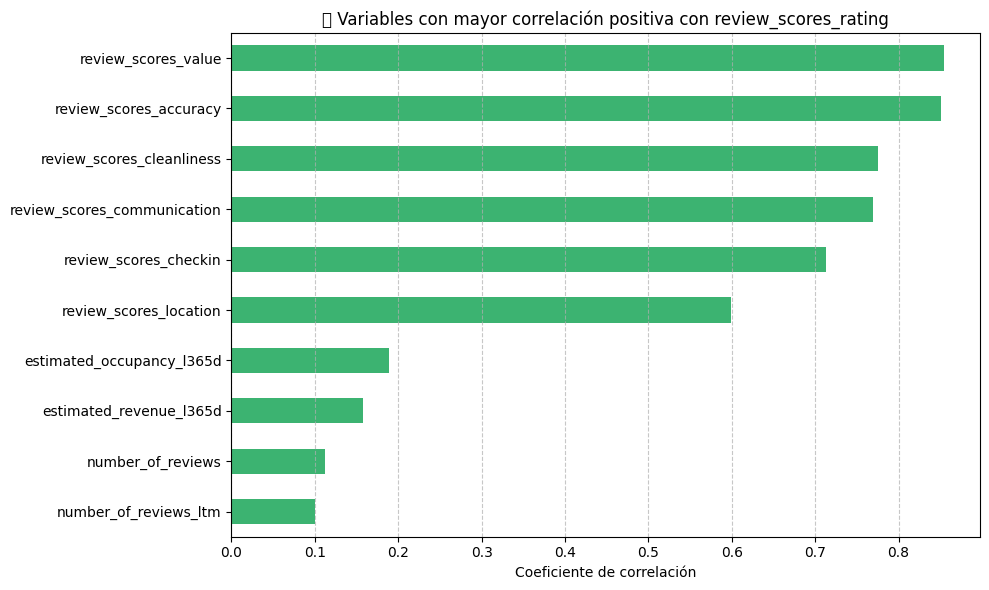

In [ ]:
import matplotlib.pyplot as plt

# Seleccionar las 10 variables con mayor correlación positiva
top_variables = correlaciones_ordenadas.head(10)

# Gráfico de barras
plt.figure(figsize=(10, 6))
top_variables.plot(kind="barh", color="mediumseagreen")
plt.title("🔍 Variables con mayor correlación positiva con review_scores_rating")
plt.xlabel("Coeficiente de correlación")
plt.gca().invert_yaxis()  # Para que la más alta aparezca arriba
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Conclusion: no hay variables relevantes que influyan en el score del reviews // estimed ocupancy tiene cierta coorelacion con reviews score, porlo que una buena score invlucrará una mayor ocupancy.

In [ ]:
import pandas as pd

# Leer solo la columna de interés
df = pd.read_csv("listings.csv.gz", compression="gzip", usecols=["neighbourhood"])

# Ver valores únicos
valores_unicos = df["neighbourhood"].dropna().unique()

# Mostrar resultados
print(f"🔍 Se encontraron {len(valores_unicos)} vecindarios únicos:\n")
for barrio in sorted(valores_unicos):
    print("-", barrio)


🔍 Se encontraron 51 vecindarios únicos:

- *, Barcelona, Spain
- ., Barcelona, Spain
- 3-1, Barcelona, Spain
- BARCELONA, Catalunya, Spain
- BARCELONA, SPAIN, Spain
- BARCELONA, Spain
- BARCELONA, city, Spain
- BCN, Spain
- Barcelona , Barcelona, Spain
- Barcelona , CT, Spain
- Barcelona , Catalonia, Spain
- Barcelona , Catalunya, Spain
- Barcelona Ciutat Vella, Barcelona, Spain
- Barcelona, *, Spain
- Barcelona, ., Spain
- Barcelona, BARCELONA, Spain
- Barcelona, Barcelona (España), Spain
- Barcelona, CATALUNYA, Spain
- Barcelona, CT, Spain
- Barcelona, Ca, Spain
- Barcelona, Catalonia, Spain
- Barcelona, Catalugna, Spain
- Barcelona, Cataluna, Spain
- Barcelona, Catalunya, ES, Barcelona, Spain
- Barcelona, Catalunya, Spain
- Barcelona, Cataluña, Catalonia, Spain
- Barcelona, España, Spain
- Barcelona, Katalonien, Spain
- Barcelona, SPAGNA, Spain
- Barcelona, Spain
- Barcelona, barcelona, Spain
- Barcelona,, Cataluña,, Spain
- Casanova, Castilla y León, Spain
- Catalunya , Spain
- Ciu

In [ ]:
import pandas as pd

# Leer el archivo original
df = pd.read_csv("listings.csv.gz", compression="gzip", usecols=["neighbourhood"])

# Crear una copia para limpiar
df_limpio = df.copy()

# Eliminar nulos
df_limpio = df_limpio.dropna(subset=["neighbourhood"])

# Normalizar: minúsculas y sin espacios extra
df_limpio["neighbourhood"] = df_limpio["neighbourhood"].str.strip().str.lower()

# Lista de valores exactos a eliminar
valores_excluir = {
    "*,barcelona,spain",
    "барселона, каталония, spain ",
    "barcelona, spain",
    "., barcelona, spain",
    "барселона","барселона, каталония, spain","*, barcelona, spain","3-1, barcelona, spain",
    "каталония",
    "spain",
    "барселона, barcelona, spain"
}

# Eliminar vecindarios que están en la lista o que empiezan por "barcelona" o "Barcelona"
df_limpio = df_limpio[
    ~df_limpio["neighbourhood"].isin(valores_excluir) &
    ~df_limpio["neighbourhood"].str.lower().str.startswith("barcelona") # Use .str.lower() before .str.startswith()
]

# Contar ocurrencias por vecindario limpio
conteo = df_limpio["neighbourhood"].value_counts()

# Mostrar resultados
print(f"🔍 Vecindarios únicos después de limpieza: {len(conteo)}")
print("\n📍 Top 10 vecindarios más frecuentes:")
print(conteo.head(10))

🔍 Vecindarios únicos después de limpieza: 16

📍 Top 10 vecindarios más frecuentes:
neighbourhood
sant adrià de besòs, catalunya, spain           13
l'hospitalet de llobregat, catalunya, spain      8
eixample, barcelona, spain                       3
gotico, barcelona, catalonia, spain              2
sagrada familia, barcelona, catalonia, spain     1
el masnou, catalonia, spain                      1
hospitalet de llobregat, ct, spain               1
sant adria de besos, barcelona, spain            1
catalunya , spain                                1
sant adrià de besòs, catalonia, spain            1
Name: count, dtype: int64


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Leer archivo con columnas necesarias
df = pd.read_csv("listings.csv.gz", compression="gzip", usecols=["neighbourhood", "price"])

# Crear copia para limpieza
df_limpio = df.copy()

# Eliminar nulos
df_limpio = df_limpio.dropna(subset=["neighbourhood", "price"])

# Normalizar: minúsculas y sin espacios extra
df_limpio["neighbourhood"] = df_limpio["neighbourhood"].str.strip().str.lower()

# Lista de valores exactos a eliminar
valores_excluir = {
    "*,barcelona,spain",
    "барселона, каталония, spain ",
    "barcelona, spain",
    "., barcelona, spain",
    "барселона","барселона, каталония, spain","*, barcelona, spain","3-1, barcelona, spain",
    "каталония",
    "spain",
    "барселона, barcelona, spain"
}

# Eliminar vecindarios que están en la lista o que empiezan por "barcelona" o "Barcelona"
df_limpio = df_limpio[
    ~df_limpio["neighbourhood"].isin(valores_excluir) &
    ~df_limpio["neighbourhood"].str.lower().str.startswith("barcelona") # Use .str.lower() before .str.startswith()
]

# Limpiar columna de precio
df_limpio["price"] = df_limpio["price"].replace("[\$,]", "", regex=True).astype(float)

# Agrupar por vecindario y calcular estadísticas
resumen = df_limpio.groupby("neighbourhood")["price"].agg(["count", "mean", "median"]).sort_values(by="mean", ascending=False)

# Mostrar top 10 vecindarios por precio promedio
print("🔝 Top 10 vecindarios con mayor precio promedio:")
print(resumen.head(10))




🔝 Top 10 vecindarios con mayor precio promedio:
                                              count        mean  median
neighbourhood                                                          
eixample, barcelona, spain                        3  282.000000   263.0
sant adria de besos, barcelona, spain             1  251.000000   251.0
sant adrià de besòs, catalunya, spain            11  243.363636   255.0
terrassa, catalunya, spain                        1  165.000000   165.0
gracia-barcelona, spain                           1  148.000000   148.0
hospitalet de llobregat, ct, spain                1  120.000000   120.0
gràcia, barcelona, spain                          1  113.000000   113.0
l'hospitalet de llobregat, catalunya, spain       7  101.428571    95.0
sagrada familia, barcelona, catalonia, spain      1  101.000000   101.0
catalunya , spain                                 1   65.000000    65.0


/tmp/ipython-input-16-1281436208.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio["neighbourhood"] = df_limpio["neighbourhood"].str.strip().str.lower()


Conclusión: Podemos ver los barrios que tienden a ser mas caros, que serviria para que un inversionista sepa en donde invertir.
Cabe recalcar que los datos no son buenos y hay mucha mezcla de idiomas y no estan bien segmentados por barrio

Conclusión: Para un inversionista esta información es útil para determinar en que barrio puede invertir. Pero hay muchas variables a tomar en cuenta, como la cantidad de apartamentos por barrio.

In [ ]:
print(listings["host_is_superhost"].head())

0      f
1    NaN
2      f
3      f
4      f
Name: host_is_superhost, dtype: object


In [ ]:
print(listings["host_is_superhost"].unique())


['f' nan 't']


In [ ]:
conteo = listings["host_is_superhost"].value_counts()
print(conteo)


host_is_superhost
f    14709
t     4159
Name: count, dtype: int64


In [ ]:
# Convertir 'host_is_superhost' a valores numéricos
listings["host_is_superhost"] = listings["host_is_superhost"].map({'t': 1, 'f': 0})

# Reemplazar NaN por 0 (opcional, si consideras que la ausencia implica no superhost)
listings["host_is_superhost"] = listings["host_is_superhost"].fillna(0).astype(int)


De las variables de Host la que mas aporta valor es Host is superhost, ya que puede tener relevacia a la hora de la puntuacion de los reviews

In [ ]:
listings["minimum_nights_avg_ntm"] = listings["minimum_nights_avg_ntm"].round()


Seria interesante saber si minimum_nights_avg_ntm tiene relevancia en los reviews

In [ ]:
print(listings["has_availability"].unique())

['t' nan 'f']


In [ ]:
# Convertir 'has_availability' a valores numéricos
listings["has_availability"] = listings["has_availability"].map({'t': 1, 'f': 0})

# Reemplazar NaN por 0 (opcional, si consideras que la ausencia implica no superhost)
listings["has_availability"] = listings["has_availability"].fillna(0).astype(int)

Has availability puede tener cierta relevancia en los reviews

🔹 R² score: 0.869
🔹 RMSE: 8172.78


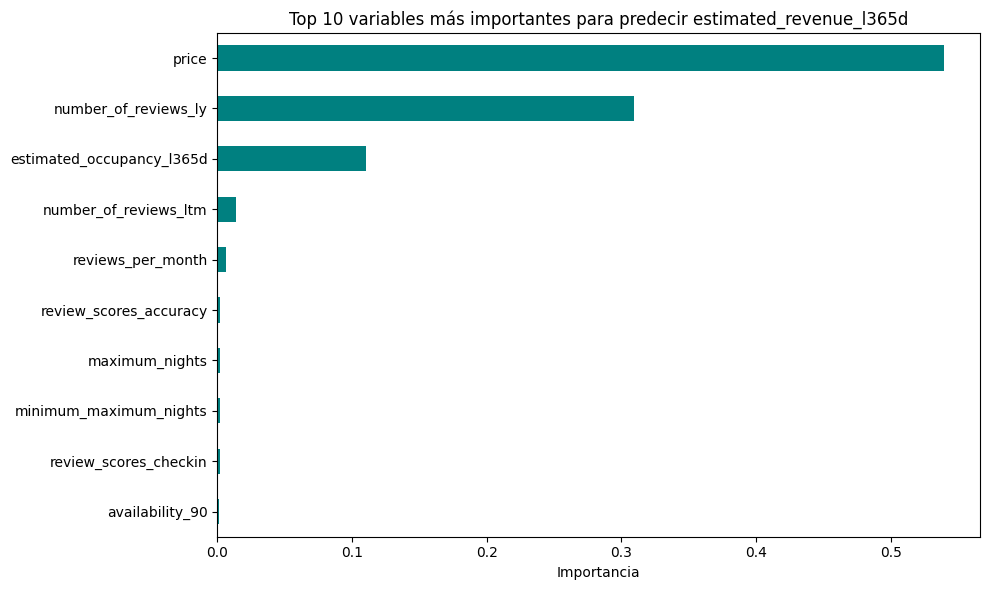

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Copia del DataFrame original
dfff = listings.copy()


# Filtrar solo columnas numéricas del DataFrame original
dfff = listings.select_dtypes(include=["int64", "float64"])

# Eliminar filas con NaN en la variable objetivo
dfff = dfff[dfff["estimated_revenue_l365d"].notnull()]

# Separar variables predictoras y objetivo
X = dfff.drop(columns="estimated_revenue_l365d")
y = dfff["estimated_revenue_l365d"]

# Eliminar filas con NaNs en X y alinear y
umbral = 0.5
X = X.loc[:, X.isnull().mean() < umbral]
X = X.dropna()
y = y.loc[X.index]
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

# ================================
# DIVISIÓN EN ENTRENAMIENTO Y PRUEBA
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# ENTRENAMIENTO DEL MODELO
# ================================
modelo = RandomForestRegressor(random_state=42)
modelo.fit(X_train, y_train)

# ================================
# EVALUACIÓN DEL MODELO
# ================================
y_pred = modelo.predict(X_test)

print(f"🔹 R² score: {r2_score(y_test, y_pred):.3f}")
print(f"🔹 RMSE: {mean_squared_error(y_test, y_pred)**0.5:.2f}")

# ================================
# IMPORTANCIA DE VARIABLES
# ================================
# Obtener las 10 variables más importantes
importancia = pd.Series(modelo.feature_importances_, index=X.columns)
top_10 = importancia.sort_values(ascending=False).head(10)

# Gráfico de barras horizontales
plt.figure(figsize=(10, 6))
top_10.sort_values().plot(kind='barh', color='teal')  # Ordenar para que la más importante quede abajo
plt.title("Top 10 variables más importantes para predecir estimated_revenue_l365d")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

Conclusión: El numero de reviews afecta el rendimiento, por lo que mas reviews es sinonimo de mas rendimiento.

🔹 R² score: 0.577
🔹 RMSE: 211.88


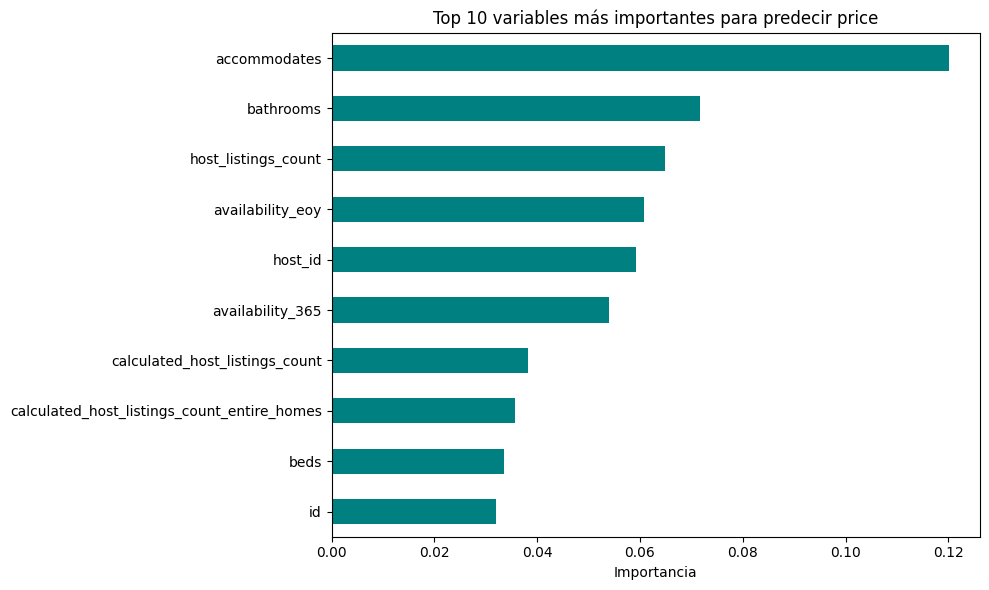

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Copia del DataFrame original
dff = listings.copy()


# Filtrar solo columnas numéricas del DataFrame original
dff = listings.select_dtypes(include=["int64", "float64"])

# Eliminar las columnas estimated_revenue_l365d, longitude, y latitude si existen
columns_to_drop = ['estimated_revenue_l365d', 'longitude', 'latitude']
for col in columns_to_drop:
    if col in dff.columns:
        dff = dff.drop(columns=col)


# Eliminar filas con NaN en la variable objetivo
dff = dff[dff["price"].notnull()]

# Separar variables predictoras y objetivo
X = dff.drop(columns="price")
y = dff["price"]

# Eliminar filas con NaNs en X y alinear y
umbral = 0.5
X = X.loc[:, X.isnull().mean() < umbral]
X = X.dropna()
y = y.loc[X.index]
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

# ================================
# DIVISIÓN EN ENTRENAMIENTO Y PRUEBA
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# ENTRENAMIENTO DEL MODELO
# ================================
modelo = RandomForestRegressor(random_state=42)
modelo.fit(X_train, y_train)

# ================================
# EVALUACIÓN DEL MODELO
# ================================
y_pred = modelo.predict(X_test)

print(f"🔹 R² score: {r2_score(y_test, y_pred):.3f}")
print(f"🔹 RMSE: {mean_squared_error(y_test, y_pred)**0.5:.2f}")

# ================================
# IMPORTANCIA DE VARIABLES
# ================================
# Obtener las 10 variables más importantes
importancia = pd.Series(modelo.feature_importances_, index=X.columns)
top_10 = importancia.sort_values(ascending=False).head(10)

# Gráfico de barras horizontales
plt.figure(figsize=(10, 6))
top_10.sort_values().plot(kind='barh', color='teal')  # Ordenar para que la más importante quede abajo
plt.title("Top 10 variables más importantes para predecir price")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

In [ ]:
palabras_clave = [
    "tv", "coffee maker", "refrigerator", "host greets you", "travel crib",
    "iron", "city skyline view", "sea view", "parking",
    "wifi", "dishes and silverware", "elevator", "hair dryer", "ac",
    "washing machine", "beach", "cot", "cleaning", "shampoo", "essentials","dishes","silverware","kitchen","heating","air conditioning", "cooking basics", "washer", "bed linens"
]


listings["amenities_lower"] = listings["amenities"].str.lower()

for palabra in palabras_clave:
    columna = f"kw_{palabra}"
    listings[columna] = listings["amenities_lower"].str.contains(palabra, regex=False).astype(int)

Conclusion: el numero de personas que admite al paramento asi como el numero de baños inlfuyen en el precio; es interesante tambien que los reviews al mes pueden tener una pequeña importancia.

🔹 R² score: -0.111
🔹 RMSE: 281.27


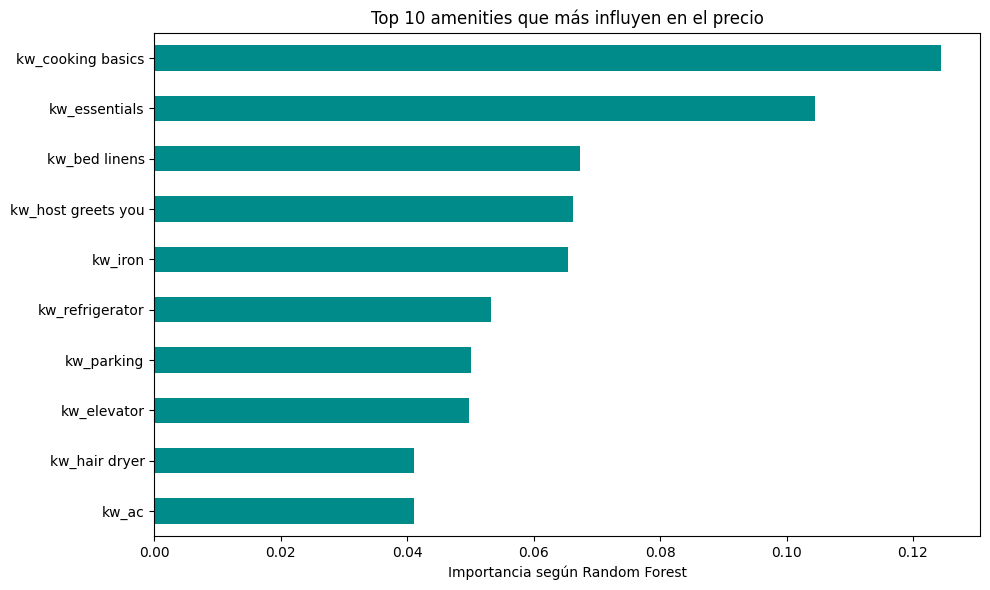

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


# Crear columnas binarias para cada palabra clave
for palabra in palabras_clave:
    columna = f"kw_{palabra}"
    listings[columna] = listings["amenities_lower"].str.contains(palabra, regex=False).astype(int)

# ================================
# 2. DEFINIR VARIABLES PARA EL MODELO
# ================================
columnas_kw = [f"kw_{palabra}" for palabra in palabras_clave if f"kw_{palabra}" in listings.columns]

# Combinar X e y para eliminar filas con NaNs en cualquiera de los dos
df_modelo = listings[columnas_kw + ["price"]].dropna()

# Separar nuevamente X e y
X = df_modelo.drop(columns="price")
y = df_modelo["price"]
# ================================
# 3. ENTRENAMIENTO DEL MODELO
# ================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = RandomForestRegressor(random_state=42)
modelo.fit(X_train, y_train)

# ================================
# 4. EVALUACIÓN DEL MODELO
# ================================
y_pred = modelo.predict(X_test)

print(f"🔹 R² score: {r2_score(y_test, y_pred):.3f}")
print(f"🔹 RMSE: {mean_squared_error(y_test, y_pred)**0.5:.2f}")

# ================================
# 5. IMPORTANCIA DE VARIABLES
# ================================
importancia = pd.Series(modelo.feature_importances_, index=X.columns)
top_10 = importancia.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_10.sort_values().plot(kind="barh", color="darkcyan")
plt.title("Top 10 amenities que más influyen en el precio")
plt.xlabel("Importancia según Random Forest")
plt.tight_layout()
plt.show()

Los amenities no tienen un impacto importante en la subida de precio, pero podemos ver que vooking basics es el amenitie mas importante.::

🔹 R² score: 0.029
🔹 RMSE: 0.51


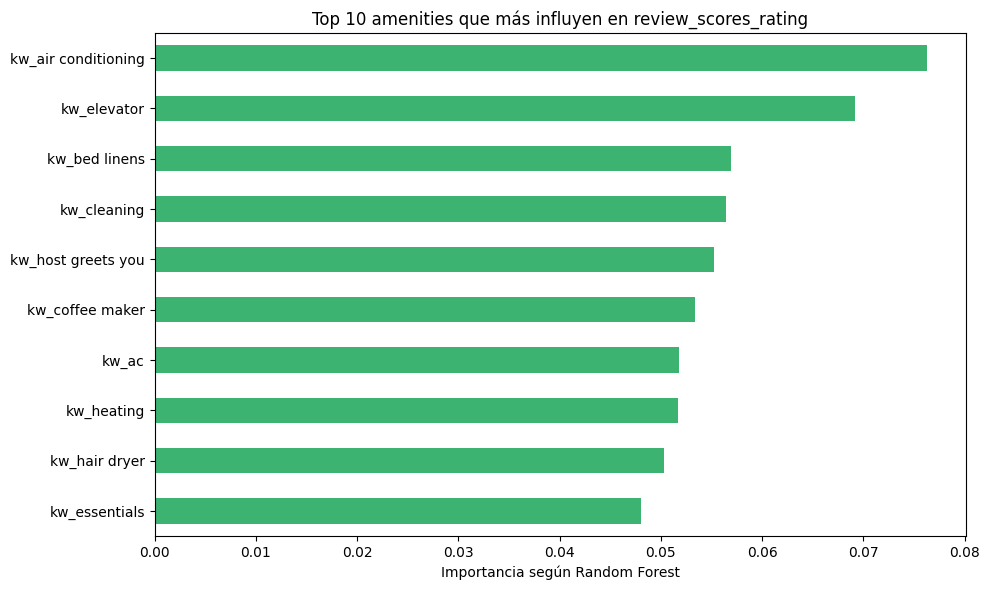

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# ================================
# 1. CREAR VARIABLES BINARIAS DE AMENITIES
# ================================
palabras_clave = [
    "tv", "coffee maker", "refrigerator", "host greets you", "travel crib",
    "iron", "city skyline view", "sea view", "parking",
    "wifi", "dishes and silverware", "elevator", "hair dryer", "ac",
    "washing machine", "beach", "cot", "cleaning", "shampoo", "essentials",
    "dishes", "silverware", "kitchen", "heating", "air conditioning",
    "cooking basics", "washer", "bed linens"
]

# Asegurar que amenities esté en minúsculas
listings["amenities_lower"] = listings["amenities"].str.lower()

# Crear columnas binarias para cada palabra clave
for palabra in palabras_clave:
    columna = f"kw_{palabra}"
    listings[columna] = listings["amenities_lower"].str.contains(palabra, regex=False).astype(int)

# ================================
# 2. DEFINIR VARIABLES PARA EL MODELO
# ================================
columnas_kw = [f"kw_{palabra}" for palabra in palabras_clave if f"kw_{palabra}" in listings.columns]

# Crear DataFrame combinado y eliminar NaNs
df_modelo = listings[columnas_kw + ["review_scores_rating"]].dropna()

# Separar X e y
X = df_modelo.drop(columns="review_scores_rating")
y = df_modelo["review_scores_rating"]

# ================================
# 3. ENTRENAMIENTO DEL MODELO
# ================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = RandomForestRegressor(random_state=42)
modelo.fit(X_train, y_train)

# ================================
# 4. EVALUACIÓN DEL MODELO
# ================================
y_pred = modelo.predict(X_test)

print(f"🔹 R² score: {r2_score(y_test, y_pred):.3f}")
print(f"🔹 RMSE: {mean_squared_error(y_test, y_pred)**0.5:.2f}")

# ================================
# 5. IMPORTANCIA DE VARIABLES
# ================================
importancia = pd.Series(modelo.feature_importances_, index=X.columns)
top_10 = importancia.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_10.sort_values().plot(kind="barh", color="mediumseagreen")
plt.title("Top 10 amenities que más influyen en review_scores_rating")
plt.xlabel("Importancia según Random Forest")
plt.tight_layout()
plt.show()

Los amenities no tienen un impacto importante en la subida de reviews, pero podemos ver que vooking basics es el amenitie mas air conditioning

In [ ]:
palabras_clave = [
    "tv", "coffee maker", "refrigerator", "host greets you", "travel crib",
    "iron", "city skyline view", "sea view", "parking",
    "wifi", "dishes and silverware", "elevator", "hair dryer", "ac",
    "washing machine", "beach", "cot", "cleaning", "shampoo", "essentials","dishes","silverware","kitchen","heating","air conditioning", "cooking basics", "washer", "bed linens"
]


listings["amenities_lower"] = listings["amenities"].str.lower()

for palabra in palabras_clave:
    columna = f"kw_{palabra}"
    listings[columna] = listings["amenities_lower"].str.contains(palabra, regex=False).astype(int)

Convertimos los amenities mas importantes en variables para el próximo modelo


Revisar si hay Outliers y eliminarlos

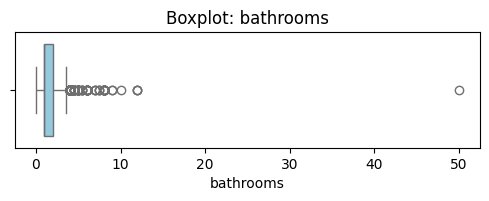

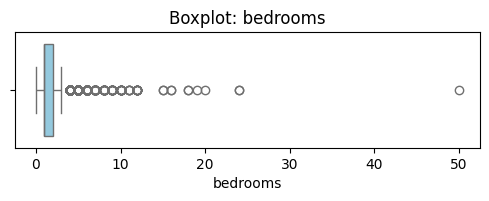

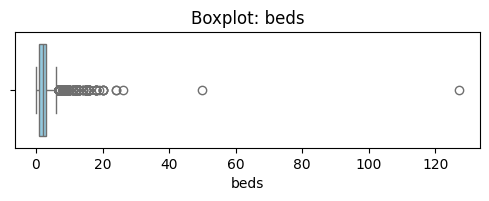

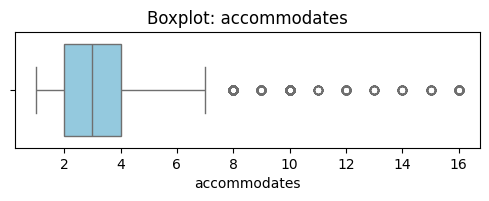

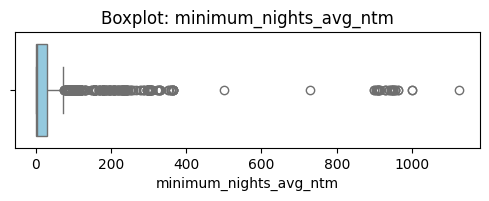

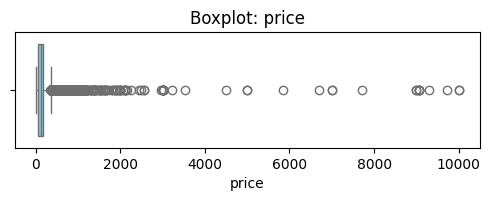

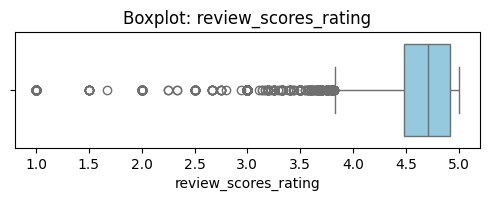

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

columnas_numericas = [
     "bathrooms", "bedrooms", "beds", "accommodates",
    "minimum_nights_avg_ntm", "price", "review_scores_rating"
]

# Visualizar valores atípicos con boxplots
for col in columnas_numericas:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(x=listings[col], color="skyblue")
    plt.title(f'Boxplot: {col}')
    plt.show()


In [ ]:
# Primero: asegurarte de que las columnas sean numéricas (por si alguna viene como texto)
columnas_convertir = [ "bathrooms", "bedrooms", "beds", "accommodates",
    "minimum_nights_avg_ntm", "price", "review_scores_rating"]
for col in columnas_convertir:
    listings[col] = pd.to_numeric(listings[col], errors="coerce")

# Luego: detectar valores atípicos con el método del IQR
outliers_info = {}
total_filas = len(listings)

for col in columnas_convertir:
    q1 = listings[col].quantile(0.25)
    q3 = listings[col].quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outlier_count = listings[(listings[col] < limite_inf) | (listings[col] > limite_sup)].shape[0]
    outlier_percentage = (outlier_count / total_filas) * 100
    outliers_info[col] = {"Count": outlier_count, "Percentage": round(outlier_percentage, 2)}

# Mostrar columnas con cantidad de outliers y porcentaje
print("Cantidad y porcentaje de valores atípicos por columna (usando IQR):\n")
for col, info in outliers_info.items():
    print(f"- {col}: {info['Count']} outliers ({info['Percentage']}%)")

Cantidad y porcentaje de valores atípicos por columna (usando IQR):

- bathrooms: 233 outliers (1.2%)
- bedrooms: 1202 outliers (6.19%)
- beds: 475 outliers (2.45%)
- accommodates: 947 outliers (4.88%)
- minimum_nights_avg_ntm: 389 outliers (2.0%)
- price: 792 outliers (4.08%)
- review_scores_rating: 681 outliers (3.51%)


In [ ]:
def eliminar_outliers(df):
    # Lista de columnas a limpiar
    columnas = [
        "bathrooms", "bedrooms", "beds", "accommodates",
        "minimum_nights_avg_ntm", "price", "review_scores_rating"
    ]

    # Crear copia del DataFrame original
    listings_filtrado = df.copy()

    for col in columnas:
        # Asegurar que la columna sea numérica
        listings_filtrado[col] = pd.to_numeric(listings_filtrado[col], errors="coerce")

        # Calcular límites usando el rango intercuartílico (IQR)
        q1 = listings_filtrado[col].quantile(0.25)
        q3 = listings_filtrado[col].quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr

        # Filtrar filas dentro del rango aceptable
        listings_filtrado = listings_filtrado[
            (listings_filtrado[col] >= lim_inf) & (listings_filtrado[col] <= lim_sup)
        ]

    return listings_filtrado





In [ ]:
def eliminar_outliers(df):
    # Lista de columnas a limpiar
    columnas = [

        "minimum_nights_avg_ntm", "price"
    ]

    # Crear copia del DataFrame original
    listings_filtrado = df.copy()

    for col in columnas:
        # Asegurar que la columna sea numérica
        listings_filtrado[col] = pd.to_numeric(listings_filtrado[col], errors="coerce")

        # Calcular límites usando el rango intercuartílico (IQR)
        q1 = listings_filtrado[col].quantile(0.25)
        q3 = listings_filtrado[col].quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - 1 * iqr
        lim_sup = q3 + 1 * iqr

        # Filtrar filas dentro del rango aceptable
        listings_filtrado = listings_filtrado[
            (listings_filtrado[col] >= lim_inf) & (listings_filtrado[col] <= lim_sup)
        ]

    return listings_filtrado


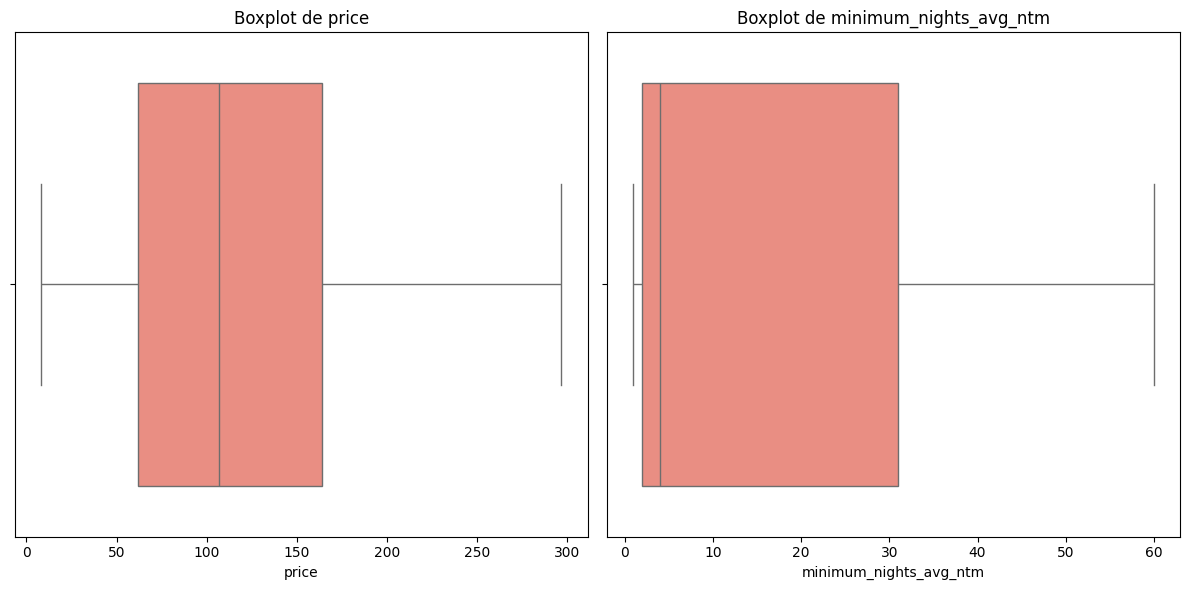

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Call the function to create the filtered DataFrame
listings_filtrado = eliminar_outliers(listings.copy())

columnas = ["price", "minimum_nights_avg_ntm"]

plt.figure(figsize=(12, 6))

for i, col in enumerate(columnas, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(x=listings_filtrado[col], color="salmon")
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

Despues de eliminar outliers con IQR, será necesario normalizar los datos

In [ ]:
import numpy as np

# Aplicar transformación logarítmica a ambas columnas
listings_filtrado["log_price"] = np.log1p(listings_filtrado["price"])
listings_filtrado["log_minimum_nights_avg_ntm"] = np.log1p(listings_filtrado["minimum_nights_avg_ntm"])



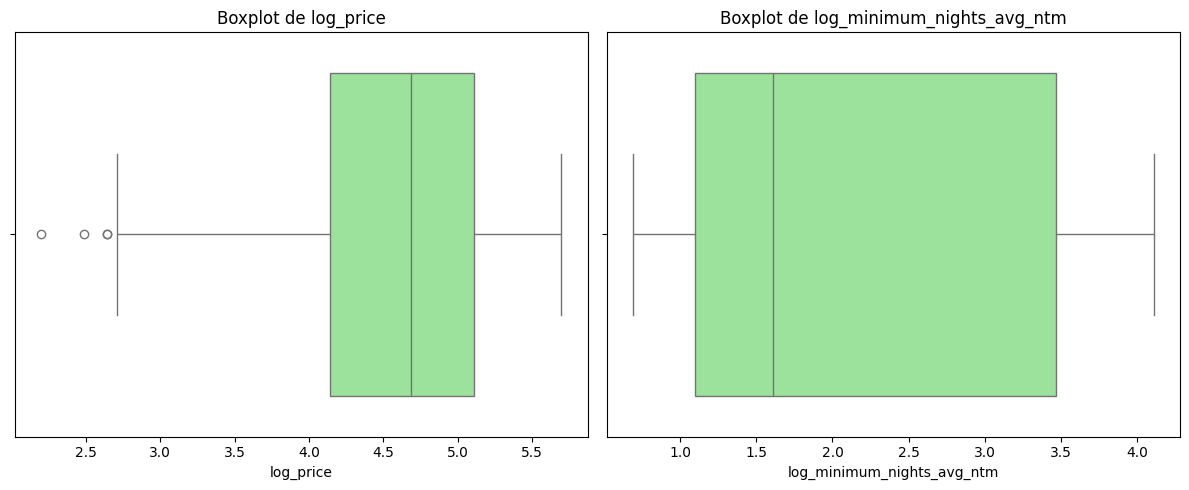

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

columnas_log = ["log_price", "log_minimum_nights_avg_ntm"]

plt.figure(figsize=(12, 5))

for i, col in enumerate(columnas_log, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(x=listings_filtrado[col], color="lightgreen")
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()


Ahora si estan en el rango de los otros datos y no se ven outliers que puedan ensuciar el modelo

In [ ]:
palabras_clave = [
    "tv", "coffee maker", "refrigerator", "host greets you", "travel crib",
    "iron", "city skyline view", "sea view", "parking",
    "wifi", "dishes and silverware", "elevator", "hair dryer", "ac",
    "washing machine", "beach", "cot", "cleaning", "shampoo", "essentials","dishes","silverware","kitchen","heating","air conditioning", "cooking basics", "washer", "bed linens"
]


listings_filtrado["amenities_lower"] = listings_filtrado["amenities"].str.lower()

for palabra in palabras_clave:
    columna = f"kw_{palabra}"
    listings_filtrado[columna] = listings_filtrado["amenities_lower"].str.contains(palabra, regex=False).astype(int)

In [ ]:
from IPython.display import display
import pandas as pd

display(listings_filtrado)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,kw_dishes,kw_silverware,kw_kitchen,kw_heating,kw_air conditioning,kw_cooking basics,kw_washer,kw_bed linens,log_price,log_minimum_nights_avg_ntm
0,18674,https://www.airbnb.com/rooms/18674,20250305023237,2025-03-06,city scrape,Huge flat for 8 people close to Sagrada Familia,110m2 apartment to rent in Barcelona. Located ...,Apartment in Barcelona located in the heart of...,https://a0.muscache.com/pictures/13031453/413c...,71615,...,1,1,1,1,0,0,1,0,5.192957,1.386294
1,23197,https://www.airbnb.com/rooms/23197,20250305023237,2025-03-07,city scrape,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax",Beautiful and Spacious Apartment with Large Te...,"Strategically located in the Parc del Fòrum, a...",https://a0.muscache.com/pictures/miso/Hosting-...,90417,...,1,1,1,1,0,1,1,1,5.529429,1.386294
2,32711,https://www.airbnb.com/rooms/32711,20250305023237,2025-03-06,city scrape,Sagrada Familia area - Còrsega 1,A lovely two bedroom apartment only 250 m from...,What's nearby <br />This apartment is located...,https://a0.muscache.com/pictures/357b25e4-f414...,135703,...,1,1,1,1,0,1,1,0,4.653960,0.693147
3,34241,https://www.airbnb.com/rooms/34241,20250305023237,2025-03-05,city scrape,Stylish Top Floor Apartment - Ramblas Plaza Real,Located in close proximity to Plaza Real and L...,NaN,https://a0.muscache.com/pictures/2437facc-2fe7...,73163,...,1,1,1,1,1,1,1,1,5.062595,3.465736
5,36763,https://www.airbnb.com/rooms/36763,20250305023237,2025-03-10,city scrape,In front of the beach,NaN,"The neighbordhood is just at the beach, very c...",https://a0.muscache.com/pictures/airflow/Hosti...,158596,...,1,1,1,1,1,0,1,0,3.850148,3.465736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19416,1366022687209927819,https://www.airbnb.com/rooms/1366022687209927819,20250305023237,2025-03-10,city scrape,@Habitación Barcelona Ciudad,Thanks to the central location of this accommo...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,396940257,...,0,0,0,1,0,0,0,1,4.143135,1.098612
19417,1366108822123777508,https://www.airbnb.com/rooms/1366108822123777508,20250305023237,2025-03-06,city scrape,Habitacion Privada,"SHARED FLOOR OF 5 ROOMS, cosmopolitan atmosphe...",NaN,https://a0.muscache.com/pictures/7d0b8e77-7724...,413160011,...,1,1,1,0,0,1,1,1,3.332205,3.433987
19418,1366453124999573764,https://www.airbnb.com/rooms/1366453124999573764,20250305023237,2025-03-11,city scrape,Cozy Double Room in City Center,"Double room with double bed on shared floor, i...","The area between Urquinaona and Arc de Triomf,...",https://a0.muscache.com/pictures/miso/Hosting-...,534870364,...,0,0,1,0,0,0,0,1,4.110874,0.693147
19419,1366459989694212599,https://www.airbnb.com/rooms/1366459989694212599,20250305023237,2025-03-07,city scrape,140. Poble Sec Ent Apartment,Apartment with 2 bedrooms and 1 bathroom in th...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,396363,...,1,1,1,0,1,1,1,0,4.644391,3.526361


In [ ]:
listings_filtrado = listings_filtrado.drop(columns=["price", "minimum_nights_avg_ntm"])


Eliminamos estas columnas que al normalizar sus datos ya no son necesarias

In [ ]:
#Revisar coorelacion entre variables:

📊 Matriz de correlación entre columnas seleccionadas:

              accommodates  bathrooms  bedrooms      beds
accommodates      1.000000   0.234710  0.710863  0.640515
bathrooms         0.234710   1.000000  0.328338  0.212406
bedrooms          0.710863   0.328338  1.000000  0.613272
beds              0.640515   0.212406  0.613272  1.000000


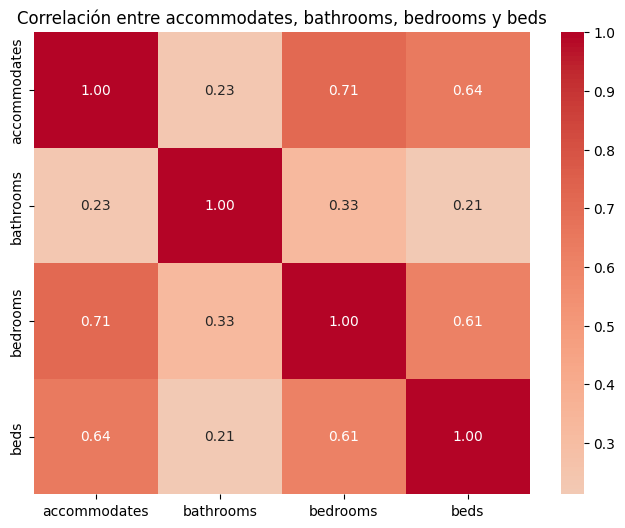

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo las columnas deseadas
columnas = ["accommodates", "bathrooms", "bedrooms", "beds"]

# Calcular la matriz de correlación
correlacion = listings_filtrado[columnas].corr()

# Mostrar la matriz en consola
print("📊 Matriz de correlación entre columnas seleccionadas:\n")
print(correlacion)

# Visualizar con heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre accommodates, bathrooms, bedrooms y beds")
plt.show()



In [ ]:
# Eliminamos beds porque tiene mucha coorelacion con bedrooms y puede cesgar el modelo
listings_filtrado = listings_filtrado.drop(columns=["beds"])


In [ ]:
print(listings_filtrado['description'].iloc[0])


110m2 apartment to rent in Barcelona. Located in the Eixample district, near the Sagrada Familia. It has a small balcony where you can see the temple of Gaudi. Capacity for 8 people. <br /><br />Licence number: HUTB-002062


In [ ]:
# Eliminamos descriptcion porque tiene valores muy variables, dificiles de usar en el modelo
listings_filtrado = listings_filtrado.drop(columns=["description"])


In [ ]:
from IPython.display import display
import pandas as pd

# List of columns to drop
columns_to_drop = [
    "scrape_id",
    "last_scraped",
    "source",
    "name",
    "neighborhood_overview",
    "picture_url",
    "host_id",
    "host_url",
    "host_name",
    # Added columns to drop
    "listing_url"
]

# Drop the columns if they exist in the DataFrame
columns_to_drop_existing = [col for col in columns_to_drop if col in listings_filtrado.columns]
listings_filtrado = listings_filtrado.drop(columns=columns_to_drop_existing)

display(listings_filtrado)

,id,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,...,kw_dishes,kw_silverware,kw_kitchen,kw_heating,kw_air conditioning,kw_cooking basics,kw_washer,kw_bed linens,log_price,log_minimum_nights_avg_ntm
0,18674,2010-01-19,"Barcelona, Spain","We are Mireia (47) & Maria (49), two multiling...",within an hour,99%,91%,0,https://a0.muscache.com/im/pictures/user/User-...,https://a0.muscache.com/im/pictures/user/User-...,...,1,1,1,1,0,0,1,0,5.192957,1.386294
1,23197,2010-03-09,"Catalonia, Spain","Hi there, \nI'm marnie from Australia, though ...",within an hour,100%,95%,0,https://a0.muscache.com/im/pictures/user/44b56...,https://a0.muscache.com/im/pictures/user/44b56...,...,1,1,1,1,0,1,1,1,5.529429,1.386294
2,32711,2010-05-31,"Barcelona, Spain",I'm Nick your English host in Barcelona.\r\n\r...,within an hour,100%,100%,0,https://a0.muscache.com/im/users/135703/profil...,https://a0.muscache.com/im/users/135703/profil...,...,1,1,1,1,0,1,1,0,4.653960,0.693147
3,34241,2010-01-24,"Barcelona, Spain","Hello I am a Professional designer, a traveler...",within an hour,100%,97%,0,https://a0.muscache.com/im/pictures/user/9cbe7...,https://a0.muscache.com/im/pictures/user/9cbe7...,...,1,1,1,1,1,1,1,1,5.062595,3.465736
5,36763,2010-07-05,"Barcelona, Spain","I live in a neighborhood ""Barceloneta"" next to...",NaN,NaN,14%,0,https://a0.muscache.com/im/pictures/user/User-...,https://a0.muscache.com/im/pictures/user/User-...,...,1,1,1,1,1,0,1,0,3.850148,3.465736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19416,1366022687209927819,2021-04-14,"Barcelona, Spain",NaN,within an hour,100%,100%,0,https://a0.muscache.com/im/pictures/user/User-...,https://a0.muscache.com/im/pictures/user/User-...,...,0,0,0,1,0,0,0,1,4.143135,1.098612
19417,1366108822123777508,2021-07-15,"Barcelona, Spain",NaN,within an hour,100%,97%,0,https://a0.muscache.com/im/pictures/user/User-...,https://a0.muscache.com/im/pictures/user/User-...,...,1,1,1,0,0,1,1,1,3.332205,3.433987
19418,1366453124999573764,2023-08-31,NaN,NaN,within an hour,97%,100%,0,https://a0.muscache.com/im/pictures/user/88762...,https://a0.muscache.com/im/pictures/user/88762...,...,0,0,1,0,0,0,0,1,4.110874,0.693147
19419,1366459989694212599,2011-02-17,"Barcelona, Spain",We are Alcambarcelona. We love our work and ar...,within an hour,100%,93%,0,https://a0.muscache.com/im/pictures/user/61a1c...,https://a0.muscache.com/im/pictures/user/61a1c...,...,1,1,1,0,1,1,1,0,4.644391,3.526361


In [ ]:
# prompt: solo quiero quedarme con las columnas: neighbourhood_group_cleansed, accommodates, bathrooms, bedrooms, log_price, log_minimum_nights_avg_ntm, number_of_reviews, 44. estimated_occupancy_l365d
# 45. estimated_revenue_l365dreviews_per_month
# 62. kw_tv
# 63. kw_coffee maker
# 64. kw_refrigerator
# 65. kw_host greets you
# 66. kw_travel crib
# 67. kw_iron
# 68. kw_city skyline view
# 69. kw_sea view
# 70. kw_parking
# 71. kw_wifi
# 72. kw_dishes and silverware
# 73. kw_elevator
# 74. kw_hair dryer
# 75. kw_ac
# 76. kw_washing machine
# 77. kw_beach
# 78. kw_cot
# 79. kw_cleaning
# 80. kw_shampoo
# 81. kw_essentials
# 82. kw_dishes
# 83. kw_silverware
# 84. kw_kitchen
# 85. kw_heating
# 86. kw_air conditioning
# 87. kw_cooking basics
# 88. kw_washer
# 89. kw_bed linens, 48. review_scores_rating, 54. review_scores_value y convierte neighbourhood_group_cleansed en una variable numerica

import pandas as pd
columnas_seleccionadas = [
    'neighbourhood_group_cleansed',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'log_price',
    'log_minimum_nights_avg_ntm',
    'number_of_reviews',
    'estimated_occupancy_l365d',
    'estimated_revenue_l365d',
    'reviews_per_month',
    'kw_tv',
    'kw_coffee maker',
    'kw_refrigerator',
    'kw_host greets you',
    'kw_travel crib',
    'kw_iron',
    'kw_city skyline view',
    'kw_sea view',
    'kw_parking',
    'kw_wifi',
    'kw_dishes and silverware',
    'kw_elevator',
    'kw_hair dryer',
    'kw_ac',
    'kw_washing machine',
    'kw_beach',
    'kw_cot',
    'kw_cleaning',
    'kw_shampoo',
    'kw_essentials',
    'kw_dishes',
    'kw_silverware',
    'kw_kitchen',
    'kw_heating',
    'kw_air conditioning',
    'kw_cooking basics',
    'kw_washer',
    'kw_bed linens',
    'review_scores_rating'
]

# Seleccionar solo las columnas deseadas
df_final = listings_filtrado[columnas_seleccionadas].copy()

# Convertir 'neighbourhood_group_cleansed' a variable numérica usando one-hot encoding
df_final = pd.get_dummies(df_final, columns=['neighbourhood_group_cleansed'], drop_first=True)

print(df_final.head())
print(df_final.info())


   accommodates  bathrooms  bedrooms  log_price  log_minimum_nights_avg_ntm  \
0             8        2.0       3.0   5.192957                    1.386294   
1             5        2.0       3.0   5.529429                    1.386294   
2             6        1.5       2.0   4.653960                    0.693147   
3             2        1.0       1.0   5.062595                    3.465736   
5             1        1.0       1.0   3.850148                    3.465736   

   number_of_reviews  estimated_occupancy_l365d  estimated_revenue_l365d  \
0                 45                         30                   5370.0   
1                 82                         48                  12048.0   
2                143                        186                  19344.0   
3                 25                        255                  40035.0   
5                108                          0                      0.0   

   reviews_per_month  kw_tv  ...  review_scores_rating  \
0         

Modelo para predecir reviews score

📊 Evaluación del modelo de Random Forest para review_scores_rating:
🔹 R² score: 0.168
🔹 RMSE: 0.45


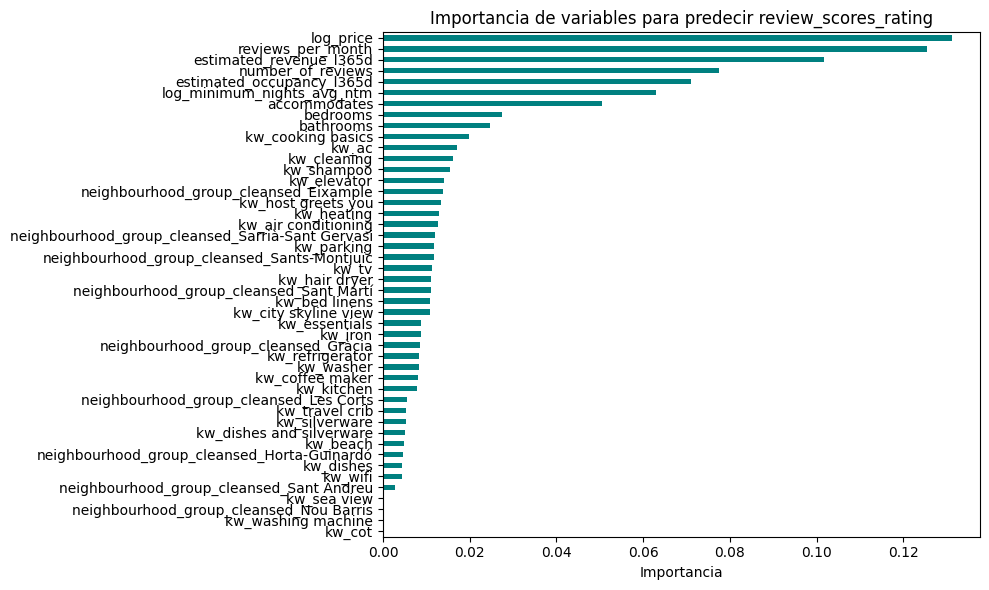

In [ ]:
# ================================
# IMPORTAR LIBRERÍAS
# ================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np # Import numpy for isnull()

# ================================
# PREPARACIÓN DE DATOS
# ================================

# Use the df_final DataFrame as the input for the model
df_model_reviews = df_final.copy()

# Ensure all columns in df_model_reviews are numeric.
# df_final was already intended to be numeric after get_dummies,
# but this step helps catch potential non-numeric columns if df_final's creation was altered.
df_model_reviews = df_model_reviews.apply(pd.to_numeric, errors='coerce')

# Drop any columns that could not be converted to numeric after coercion
df_model_reviews = df_model_reviews.dropna(axis=1, how='all')


# Ensure the target variable is not null
df_model_reviews = df_model_reviews[df_model_reviews["review_scores_rating"].notnull()].copy()


# ================================
# DEFINIR VARIABLES
# ================================
X = df_model_reviews.drop(columns="review_scores_rating")
y = df_model_reviews["review_scores_rating"]

# 🔧 Handle NaNs in X: Drop columns with high percentage of NaNs, then drop remaining rows with NaNs
umbral = 0.5 # Keep columns with less than 50% missing values
X = X.loc[:, X.isnull().mean() < umbral]

# Drop rows with remaining NaNs in X and align y
X.dropna(inplace=True) # Drop rows with remaining NaNs

# Align y to the filtered X
y = y.loc[X.index]


# ================================
# DIVISIÓN EN ENTRENAMIENTO Y PRUEBA
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4
    , random_state=42
)

# ================================
# ENTRENAMIENTO DEL MODELO
# ================================
modelo = RandomForestRegressor(random_state=42)
modelo.fit(X_train, y_train)

# ================================
# EVALUACIÓN DEL MODELO
# ================================
y_pred = modelo.predict(X_test) # Predict on X_test


print(f"📊 Evaluación del modelo de Random Forest para review_scores_rating:")
print(f"🔹 R² score: {r2_score(y_test, y_pred):.3f}")
print(f"🔹 RMSE: {mean_squared_error(y_test, y_pred)**0.5:.2f}")

# ================================
# IMPORTANCIA DE VARIABLES
# ================================
importancia = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancia.plot(kind='barh', color='teal')
plt.title("Importancia de variables para predecir review_scores_rating")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

Conclusiones: no hay una variable relevante en revews score, pero una tendencia vista es que mientras mas sea el precio, los reviews tienden a ser mejores, tal vez porque mientras mas costos, mejores son los servicios. por

📊 Evaluación del modelo Random Forest:
🔹 MAE:  0.23
🔹 MSE:  0.10
🔹 RMSE: 0.31
🔹 R²:   0.738

🔁 R² promedio (cross-validation): 0.681
📉 R² por fold: [0.706 0.702 0.671 0.696 0.629]


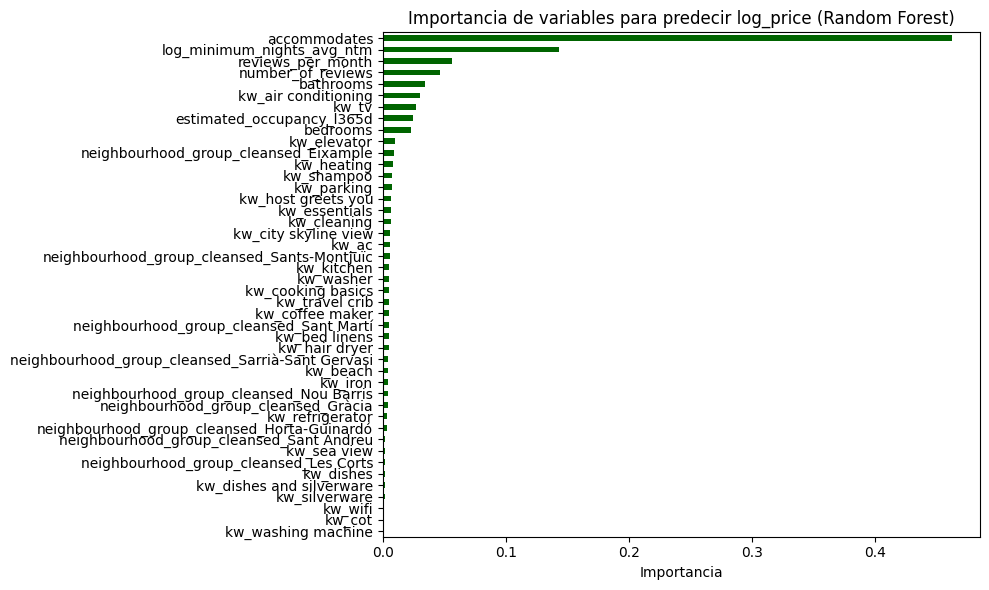


📈 Resumen del modelo de regresión lineal (statsmodels):
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.622
Method:                 Least Squares   F-statistic:                     432.3
Date:                Fri, 18 Jul 2025   Prob (F-statistic):               0.00
Time:                        16:18:39   Log-Likelihood:                -4825.6
No. Observations:               10752   AIC:                             9735.
Df Residuals:                   10710   BIC:                         1.004e+04
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm

# ================================
# DEFINIR VARIABLES X E Y
# ================================
if 'log_price' not in df_final.columns:
    print("Error: 'log_price' column not found in df_final.")
else:
    df_model_cleaned = df_final.copy()
    df_model_cleaned.dropna(subset=["log_price"], inplace=True)

    # Define columns to drop from the features
    columns_to_drop_features = [col for col in ['estimated_revenue_l365d', 'review_scores_rating'] if col in df_model_cleaned.columns]
    columns_to_drop_features += ["log_price"] # Target variable should not be in features


    X = df_model_cleaned.drop(columns=columns_to_drop_features)
    y = df_model_cleaned["log_price"]

    # 🔧 Handle NaNs in X: Drop columns with high percentage of NaNs, then drop remaining rows with NaNs
    umbral = 0.5
    X = X.loc[:, X.isnull().mean() < umbral]
    X.dropna(inplace=True)
    y = y.loc[X.index] # Align y to the filtered X

    # ================================
    # DIVISIÓN EN ENTRENAMIENTO Y PRUEBA
    # ================================
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # ================================
    # RANDOM FOREST REGRESSOR
    # ================================
    modelo_rf = RandomForestRegressor(random_state=42)
    modelo_rf.fit(X_train, y_train)
    y_pred_rf = modelo_rf.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred_rf)
    mse = mean_squared_error(y_test, y_pred_rf)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred_rf)

    print("📊 Evaluación del modelo Random Forest:")
    print(f"🔹 MAE:  {mae:.2f}")
    print(f"🔹 MSE:  {mse:.2f}")
    print(f"🔹 RMSE: {rmse:.2f}")
    print(f"🔹 R²:   {r2:.3f}")

    # ================================
    # VALIDACIÓN CRUZADA
    # ================================
    # Use the cleaned X and y from above
    cv_scores = cross_val_score(modelo_rf, X, y, cv=5, scoring="r2")
    print(f"\n🔁 R² promedio (cross-validation): {cv_scores.mean():.3f}")
    print(f"📉 R² por fold: {np.round(cv_scores, 3)}")

    # ================================
    # IMPORTANCIA DE VARIABLES
    # ================================
    importancia = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    importancia.plot(kind='barh', color='darkgreen')
    plt.title("Importancia de variables para predecir log_price (Random Forest)")
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()

    # ================================
    # REGRESIÓN LINEAL CON STATSMODELS
    # ================================
    X_sm = X.copy()

    # 🔧 Convert boolean columns to integer (0 or 1) for statsmodels
    for col in X_sm.columns:
        if X_sm[col].dtype == 'bool':
            X_sm[col] = X_sm[col].astype(int)


    # Add constant term for the intercept
    X_sm = sm.add_constant(X_sm)

    # Align X_sm and y_sm to ensure they have the same index after cleaning X
    X_sm, y_sm = X_sm.align(y, join='inner', axis=0)


    if X_sm.empty:
        print("\n⚠️ X_sm is empty after cleaning. Cannot fit statsmodels OLS model.")
    else:
        modelo_sm = sm.OLS(y_sm, X_sm).fit()
        print("\n📈 Resumen del modelo de regresión lineal (statsmodels):")
        print(modelo_sm.summary())


🔮 Predicción sin amenities: 4.29
🔮 Predicción con todos los amenities activos: 5.06
📈 Incremento estimado en review_scores_rating: 0.77 puntos


/tmp/ipython-input-49-3135038127.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Sin amenities", "Con todos activos"], y=[score_sin, score_con], palette=["gray", "mediumseagreen"])


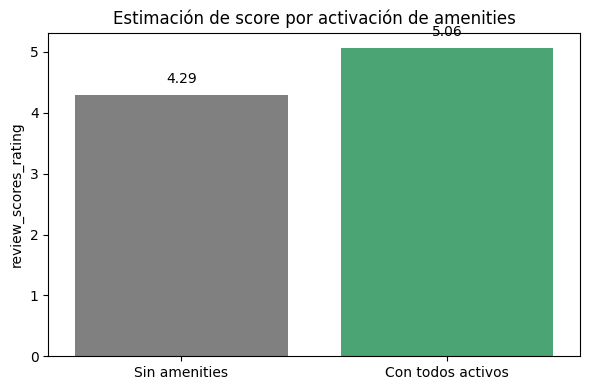

In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt

# 1. Seleccionar variables de amenities
amenities_cols = [col for col in df_model_cleaned.columns if col.startswith("kw_")]

# 2. Filtrar DataFrame para modelar
if "review_scores_rating" in df_model_cleaned.columns:
    df_amenities_model = df_model_cleaned[amenities_cols + ["review_scores_rating"]].dropna()

    # 3. Definir X e y
    X = df_amenities_model[amenities_cols]
    y = df_amenities_model["review_scores_rating"]

    # 4. Entrenar el modelo
    modelo_rating = LinearRegression()
    modelo_rating.fit(X, y)

    # 5. Simular escenarios
    # Sin amenities activos (todos 0)
    X_sin_amenities = pd.DataFrame([[0]*len(X.columns)], columns=X.columns)

    # Con todos los amenities activos (todos 1)
    X_con_amenities = pd.DataFrame([[1]*len(X.columns)], columns=X.columns)

    # 6. Predecir ambos casos
    score_sin = modelo_rating.predict(X_sin_amenities)[0]
    score_con = modelo_rating.predict(X_con_amenities)[0]
    incremento_score = score_con - score_sin

    # 7. Mostrar resultados
    print(f"\n🔮 Predicción sin amenities: {score_sin:.2f}")
    print(f"🔮 Predicción con todos los amenities activos: {score_con:.2f}")
    print(f"📈 Incremento estimado en review_scores_rating: {incremento_score:.2f} puntos")

    # 8. Visualizar
    import seaborn as sns
    plt.figure(figsize=(6, 4))
    sns.barplot(x=["Sin amenities", "Con todos activos"], y=[score_sin, score_con], palette=["gray", "mediumseagreen"])
    plt.title("Estimación de score por activación de amenities")
    plt.ylabel("review_scores_rating")
    for i, valor in enumerate([score_sin, score_con]):
        plt.text(i, valor + 0.2, f"{valor:.2f}", ha="center")
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ La columna 'review_scores_rating' no se encuentra en df_model_cleaned.")


El modelo Random Forest tuvo un mejor rendimiento que el modelo de regresión lineal en términos de R², lo que sugiere que las relaciones no lineales o las interacciones entre las características son importantes para predecir log_price.
Ambos modelos destacan características similares como importantes, siendo accommodates y log_minimum_nights_avg_ntm predictores consistentemente fuertes. Las características estructurales como bedrooms y bathrooms, así como review_scores_rating, también juegan un papel importante.
Algunas amenidades también muestran coeficientes estadísticamente significativos en el modelo lineal, lo que sugiere que tienen un impacto discernible en log_price, aunque su importancia es menor en comparación con características como accommodates y minimum_nights_avg_ntm

Basándonos en el resumen del modelo (modelo_sm.summary()), las variables que mejor explican el log_price son aquellas con valores p bajos y coeficientes con magnitudes notables. Algunas de las más destacadas son:

accommodates: Tiene un coeficiente positivo grande (0.1408) y un valor p muy bajo (0.000). Indica que la capacidad para alojar personas tiene un impacto positivo y fuerte en el log_price.
log_minimum_nights_avg_ntm: Tiene un coeficiente negativo notable (-0.1746) y un valor p muy bajo (0.000). Indica que un promedio de noches mínimo más alto se asocia con un log_price más bajo.
kw_tv: Tiene un coeficiente positivo (0.2432) y un valor p muy bajo (0.000). Sugiere que tener TV está asociado con un log_price significativamente más alto.
kw_air conditioning: Tiene un coeficiente positivo (0.2012) y un valor p muy bajo (0.000). Indica que el aire acondicionado también tiene un impacto positivo significativo.
kw_sea view: Tiene un coeficiente positivo (0.1749) y un valor p bajo (0.000). Sugiere que tener vista al mar está asociado con un log_price más alto.
kw_host greets you: Tiene un coeficiente negativo (-0.0831) y un valor p muy bajo (0.000). Curiosamente, sugiere que si el anfitrión te recibe personalmente está asociado con un log_price ligeramente más bajo en este modelo lineal.
kw_heating: Tiene un coeficiente positivo (0.0823) y un valor p muy bajo (0.000). Indica que la calefacción también es un factor positivo.
kw_essentials: Tiene un coeficiente positivo (0.0801) y un valor p muy bajo (0.000). Sugiere que tener lo esencial (productos básicos) también influye positivamente.
kw_hair dryer: Tiene un coeficiente positivo (0.0763) y un valor p muy bajo (0.000).
kw_cooking basics: Tiene un coeficiente negativo (-0.0745) y un valor p muy bajo (0.000). Sugiere que tener lo básico para cocinar está asociado con un log_price ligeramente más bajo en este modelo.
kw_kitchen: También tiene un coeficiente negativo (-0.0756) y un valor p muy bajo (0.000). Similar a 'cooking basics', sugiere una asociación negativa con log_price en este modelo.
host_is_superhost: Tiene un coeficiente positivo (0.0714) y un valor p muy bajo (0.000). Indica que ser Superhost está asociado con un log_price más alto.
review_scores_rating: Tiene un coeficiente positivo (0.0664) y un valor p muy bajo (0.000). Sugiere que una mejor puntuación de reviews también se relaciona con un log_price más alto.
kw_elevator: Tiene un coeficiente positivo (0.0603) y un valor p muy bajo (0.000).
kw_coffee maker: Tiene un coeficiente positivo (0.0580) y un valor p muy bajo (0.000).
bathrooms: Tiene un coeficiente positivo (0.0234) y un valor p bajo (0.005). Indica que el número de baños tiene un impacto positivo y estadísticamente significativo, aunque el coeficiente es menor que el de accommodates o bedrooms.
bedrooms: Tiene un coeficiente positivo (0.0403) y un valor p muy bajo (0.000). Indica que el número de dormitorios tiene un impacto positivo y significativo.

In [ ]:
correlaciones = df_final.corr()["review_scores_rating"].sort_values(ascending=False)
print(correlaciones)


review_scores_rating                                1.000000
estimated_occupancy_l365d                           0.239962
estimated_revenue_l365d                             0.200002
kw_ac                                               0.134751
kw_parking                                          0.133908
kw_shampoo                                          0.120604
number_of_reviews                                   0.117609
kw_cooking basics                                   0.114789
kw_hair dryer                                       0.103680
kw_coffee maker                                     0.102197
kw_beach                                            0.099172
kw_essentials                                       0.098459
kw_iron                                             0.096878
reviews_per_month                                   0.092746
kw_cleaning                                         0.091392
kw_travel crib                                      0.086275
kw_dishes and silverware

In [ ]:
import numpy as np
import pandas as pd # Import pandas if not already imported

# Obtener los coeficientes del modelo de regresión lineal
# Asegurarse de que modelo_sm está disponible (fue entrenado en la celda anterior)
if 'modelo_sm' not in locals():
    print("Error: El modelo de regresión lineal (modelo_sm) no está disponible. Por favor, ejecuta la celda donde se entrena.")
else:
    coeficientes_sm = modelo_sm.params

    # Coeficientes relevantes para bathrooms y beds
    # beds fue eliminado por multicolinealidad con bedrooms en una etapa anterior.
    # Usaremos bedrooms en su lugar, ya que beds fue muy correlacionado con bedrooms.
    # Si beds aún existiera en X_sm, usaríamos coeficientes_sm['beds']
    coeficiente_bathrooms = coeficientes_sm.get('bathrooms', 0) # Usar .get con valor por defecto 0 por si la columna no existe
    coeficiente_bedrooms = coeficientes_sm.get('bedrooms', 0)   # Usar .get con valor por defecto 0 por si la columna no existe


    print(f"Estimación del impacto de añadir un baño (basado en el coeficiente de 'bathrooms' en log_price):")
    print(f"Un aumento de 1 en 'bathrooms' se asocia con un cambio de {coeficiente_bathrooms:.4f} en log_price.")

    print(f"\nEstimación del impacto de añadir un dormitorio (basado en el coeficiente de 'bedrooms' en log_price):")
    print(f"Un aumento de 1 en 'bedrooms' se asocia con un cambio de {coeficiente_bedrooms:.4f} en log_price.")


    # ==============================================================
    # Interpretar en la escala original del precio (esto es una aproximación)
    # ==============================================================
    # Necesitamos un precio de referencia representativo de los datos modelados.
    # Usaremos la columna 'price' del DataFrame 'listings' original,
    # filtrada para incluir solo las filas que se usaron en el modelo OLS (basado en el índice de X_sm).
    # Asegurarse de que 'price' column exists and is numeric after cleaning.
    if 'price' in listings.columns and pd.api.types.is_numeric_dtype(listings['price']):
        # Get the indices of the data used for the statsmodels OLS model
        indices_usados_en_modelo_sm = X_sm.index

        # Calculate the mean of the original 'price' column from the 'listings' DataFrame,
        # filtered to include only the rows used in the statsmodels model.
        precio_referencia = listings.loc[indices_usados_en_modelo_sm, 'price'].mean()

        print(f"\nUsando un precio de referencia promedio de {precio_referencia:.2f}€ (basado en los datos modelados):")

        # Calcular el factor de cambio en el precio original
        # Un cambio de 'c' en log_price (log(price)) implica que price cambia por un factor de exp(c).
        # El aumento absoluto sería P * exp(c) - P = P * (exp(c) - 1).
        # np.expm1(c) calcula exp(c) - 1.
        factor_cambio_bathrooms = np.expm1(coeficiente_bathrooms) # exp(c) - 1
        factor_cambio_bedrooms = np.expm1(coeficiente_bedrooms) # exp(c) - 1

        # Calcular el aumento absoluto estimado en el precio original
        aumento_estimado_bathrooms = precio_referencia * factor_cambio_bathrooms
        aumento_estimado_bedrooms = precio_referencia * factor_cambio_bedrooms

        print(f"Aumento absoluto estimado en el precio original al añadir un baño: ≈ {aumento_estimado_bathrooms:.2f}€")
        print(f"Aumento absoluto estimado en el precio original al añadir un dormitorio: ≈ {aumento_estimado_bedrooms:.2f}€")

    else:
        print("\nAdvertencia: La columna 'price' en 'listings' no es numérica o no está disponible para calcular el precio de referencia.")
        print("No se puede estimar el aumento absoluto en la escala original del precio.")


    print("\nNota: Estas son estimaciones basadas en un modelo lineal sobre el logaritmo del precio y deben interpretarse con precaución.")
    print("El impacto real puede variar para listados específicos debido a otros factores y relaciones no lineales.")

Estimación del impacto de añadir un baño (basado en el coeficiente de 'bathrooms' en log_price):
Un aumento de 1 en 'bathrooms' se asocia con un cambio de -0.0482 en log_price.

Estimación del impacto de añadir un dormitorio (basado en el coeficiente de 'bedrooms' en log_price):
Un aumento de 1 en 'bedrooms' se asocia con un cambio de 0.0354 en log_price.

Usando un precio de referencia promedio de 123.39€ (basado en los datos modelados):
Aumento absoluto estimado en el precio original al añadir un baño: ≈ -5.81€
Aumento absoluto estimado en el precio original al añadir un dormitorio: ≈ 4.45€

Nota: Estas son estimaciones basadas en un modelo lineal sobre el logaritmo del precio y deben interpretarse con precaución.
El impacto real puede variar para listados específicos debido a otros factores y relaciones no lineales.


In [ ]:
import numpy as np
import pandas as pd # Import pandas if not already imported

# Obtener los coeficientes del modelo de regresión lineal
# Asegurarse de que modelo_sm está disponible (fue entrenado en la celda anterior)
if 'modelo_sm' not in locals():
    print("Error: El modelo de regresión lineal (modelo_sm) no está disponible. Por favor, ejecuta la celda donde se entrena.")
else:
    coeficientes_sm = modelo_sm.params

    # Coeficientes relevantes para accommodates y review_scores_rating
    coeficiente_accommodates = coeficientes_sm.get('accommodates', 0)
    coeficiente_review_scores_rating = coeficientes_sm.get('review_scores_rating', 0)

    print(f"Estimación del impacto de añadir una persona a la capacidad (basado en el coeficiente de 'accommodates' en log_price):")
    print(f"Un aumento de 1 en 'accommodates' se asocia con un cambio de {coeficiente_accommodates:.4f} en log_price.")

    print(f"\nEstimación del impacto de mejorar la puntuación de reviews en un punto (basado en el coeficiente de 'review_scores_rating' en log_price):")
    print(f"Un aumento de 1 en 'review_scores_rating' se asocia con un cambio de {coeficiente_review_scores_rating:.4f} en log_price.")


    # ==============================================================
    # Interpretación en la escala original del precio (usando el precio de referencia)
    # Necesitamos el precio promedio de los datos usados en el modelo statsmodels.
    # Usaremos la columna 'price' del DataFrame 'listings' original,
    # filtrada para incluir solo las filas que se usaron en el modelo OLS (basado en el índice de X_sm).
    # Ensure 'price' column exists and is numeric after cleaning.
    if 'price' in listings.columns and pd.api.types.is_numeric_dtype(listings['price']):
        # Get the indices of the data used for the statsmodels OLS model
        indices_usados_en_modelo_sm = X_sm.index

        # Calculate the mean of the original 'price' column from the 'listings' DataFrame,
        # filtered to include only the rows used in the statsmodels model.
        precio_referencia = listings.loc[indices_usados_en_modelo_sm, 'price'].mean()


        print(f"\nUsando un precio de referencia promedio de {precio_referencia:.2f}€ (en la escala original de los datos usados para el modelo):")

        # Calcular el factor de cambio en el precio original
        factor_cambio_accommodates = np.expm1(coeficiente_accommodates) # exp(c) - 1
        factor_cambio_review_scores_rating = np.expm1(coeficiente_review_scores_rating) # exp(c) - 1

        # Calcular el aumento absoluto estimado en el precio original
        aumento_estimado_accommodates = precio_referencia * factor_cambio_accommodates
        aumento_estimado_review_scores_rating = precio_referencia * factor_cambio_review_scores_rating


        print(f"Aumento absoluto estimado en el precio original al añadir una persona a la capacidad: ≈ {aumento_estimado_accommodates:.2f}€")
        print(f"Aumento absoluto estimado en el precio original al mejorar la puntuación de reviews en un punto: ≈ {aumento_estimado_review_scores_rating:.2f}€")

    else:
        print("\nAdvertencia: La columna 'price' en 'listings' no es numérica o no está disponible para calcular el precio de referencia.")
        print("No se puede estimar el aumento absoluto en la escala original del precio.")


    print("\nNota: Estas son estimaciones basadas en un modelo lineal sobre el logaritmo del precio y deben interpretarse con precaución.")
    print("El impacto real puede variar para listados específicos debido a otros factores y relaciones no lineales.")

Estimación del impacto de añadir una persona a la capacidad (basado en el coeficiente de 'accommodates' en log_price):
Un aumento de 1 en 'accommodates' se asocia con un cambio de 0.1352 en log_price.

Estimación del impacto de mejorar la puntuación de reviews en un punto (basado en el coeficiente de 'review_scores_rating' en log_price):
Un aumento de 1 en 'review_scores_rating' se asocia con un cambio de 0.0000 en log_price.

Usando un precio de referencia promedio de 123.39€ (en la escala original de los datos usados para el modelo):
Aumento absoluto estimado en el precio original al añadir una persona a la capacidad: ≈ 17.86€
Aumento absoluto estimado en el precio original al mejorar la puntuación de reviews en un punto: ≈ 0.00€

Nota: Estas son estimaciones basadas en un modelo lineal sobre el logaritmo del precio y deben interpretarse con precaución.
El impacto real puede variar para listados específicos debido a otros factores y relaciones no lineales.


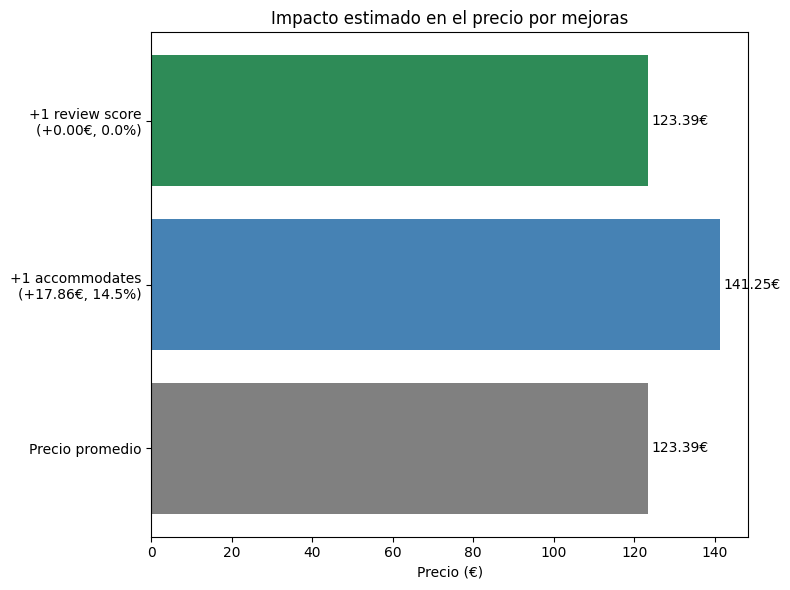

In [ ]:
import matplotlib.pyplot as plt

# Asegúrate de que este bloque se ejecuta solo si se tiene el precio_referencia
if 'precio_referencia' in locals():
    # Calculamos precios ajustados
    precio_accommodates = precio_referencia + aumento_estimado_accommodates
    precio_reviews = precio_referencia + aumento_estimado_review_scores_rating

    # Datos para graficar
    precios = [precio_referencia, precio_accommodates, precio_reviews]
    etiquetas = [
        "Precio promedio",
        f"+1 accommodates\n(+{aumento_estimado_accommodates:.2f}€, {factor_cambio_accommodates*100:.1f}%)",
        f"+1 review score\n(+{aumento_estimado_review_scores_rating:.2f}€, {factor_cambio_review_scores_rating*100:.1f}%)"
    ]

    # Crear gráfico
    plt.figure(figsize=(8, 6))
    barras = plt.barh(etiquetas, precios, color=["gray", "steelblue", "seagreen"])
    plt.title("Impacto estimado en el precio por mejoras")
    plt.xlabel("Precio (€)")

    # Añadir etiquetas en las barras
    for barra in barras:
        valor = barra.get_width()
        plt.text(valor + 1, barra.get_y() + barra.get_height() / 2,
                 f"{valor:.2f}€", va="center")

    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import pandas as pd # Import pandas if not already imported

# Obtener los coeficientes del modelo de regresión lineal
# Asegurarse de que modelo_sm está disponible (fue entrenado en la celda anterior)
if 'modelo_sm' not in locals() or 'X_sm' not in locals():
    print("Error: El modelo de regresión lineal (modelo_sm) o los datos (X_sm) no están disponibles.")
    print("Por favor, ejecuta la celda donde se entrena el modelo OLS.")
else:
    coeficientes_sm = modelo_sm.params

    # Coeficiente relevante para host_is_superhost
    # Ensure 'host_is_superhost' is in the model coefficients
    if 'host_is_superhost' not in coeficientes_sm.index:
        print("Advertencia: La variable 'host_is_superhost' no se encuentra en los coeficientes del modelo OLS.")
        coeficiente_superhost = 0
    else:
         coeficiente_superhost = coeficientes_sm['host_is_superhost']


    print(f"Estimación del impacto de cambiar el estado a Superhost (basado en el coeficiente de 'host_is_superhost' en log_price):")
    print(f"Un cambio de 0 a 1 en 'host_is_superhost' se asocia con un cambio de {coeficiente_superhost:.4f} en log_price.")


    # ==============================================================
    # Interpretación en la escala original del precio (usando el precio de referencia)
    # Necesitamos un precio de referencia representativo de los datos modelados.
    # Usaremos la columna 'price' del DataFrame 'listings' original,
    # filtrada para incluir solo las filas que se usaron en el modelo OLS (basado en el índice de X_sm).
    # Ensure 'price' column exists and is numeric after cleaning.
    if 'price' in listings.columns and pd.api.types.is_numeric_dtype(listings['price']):
        # Get the indices of the data used for the statsmodels OLS model
        indices_usados_en_modelo_sm = X_sm.index

        # Calculate the mean of the original 'price' column from the 'listings' DataFrame,
        # filtered to include only the rows used in the statsmodels model.
        # Ensure there are rows with these indices in listings
        if not listings.loc[indices_usados_en_modelo_sm].empty:
            precio_referencia = listings.loc[indices_usados_en_modelo_sm, 'price'].mean()

            print(f"\nUsando un precio de referencia promedio de {precio_referencia:.2f}€ (basado en los datos modelados):")

            # Calcular el factor de cambio en el precio original
            factor_cambio_superhost = np.expm1(coeficiente_superhost) # exp(c) - 1

            # Calcular el aumento absoluto estimado en el precio original
            aumento_estimado_superhost = precio_referencia * factor_cambio_superhost

            print(f"Aumento absoluto estimado en el precio original al cambiar a Superhost: ≈ {aumento_estimado_superhost:.2f}€")

        else:
             print("\nAdvertencia: No se encontraron filas correspondientes a los índices del modelo en el DataFrame 'listings' original para calcular el precio de referencia.")
             print("No se puede estimar el aumento absoluto en la escala original del precio.")


    else:
        print("\nAdvertencia: La columna 'price' en 'listings' no es numérica o no está disponible para calcular el precio de referencia.")
        print("No se puede estimar el aumento absoluto en la escala original del precio.")


    print("\nNota: Esta es una estimación basada en un modelo lineal sobre el logaritmo del precio y debe interpretarse con precaución.")
    print("El impacto real puede variar para listados específicos debido a otros factores y relaciones no lineales.")

Advertencia: La variable 'host_is_superhost' no se encuentra en los coeficientes del modelo OLS.
Estimación del impacto de cambiar el estado a Superhost (basado en el coeficiente de 'host_is_superhost' en log_price):
Un cambio de 0 a 1 en 'host_is_superhost' se asocia con un cambio de 0.0000 en log_price.

Usando un precio de referencia promedio de 123.39€ (basado en los datos modelados):
Aumento absoluto estimado en el precio original al cambiar a Superhost: ≈ 0.00€

Nota: Esta es una estimación basada en un modelo lineal sobre el logaritmo del precio y debe interpretarse con precaución.
El impacto real puede variar para listados específicos debido a otros factores y relaciones no lineales.


In [ ]:
import numpy as np

# Obtener los coeficientes del modelo de regresión lineal
coeficientes_sm = modelo_sm.params

# Lista de amenidades a considerar para el primer escenario
amenidades_a_agregar = [
    "kw_tv",
    "kw_air conditioning",
    # "kw_host greets you", # Eliminado
    "kw_heating",
    "kw_essentials",
    "kw_coffee maker",
    "kw_hair dryer",
    # "kw_cooking basics" # Eliminado
]

# Calcular el cambio total en log_price al agregar estas amenidades
cambio_log_price_amenidades = 0
print("Cambio en log_price por cada amenidad agregada:")
for amenidad in amenidades_a_agregar:
    # Obtener el coeficiente de la amenidad (usar .get por si alguna no existe en el modelo)
    coeficiente_amenidad = coeficientes_sm.get(amenidad, 0)
    print(f"- {amenidad}: {coeficiente_amenidad:.4f}")
    # Sumar el coeficiente (asumiendo que el cambio es de 0 a 1)
    cambio_log_price_amenidades += coeficiente_amenidad

print(f"\nCambio total estimado en log_price al agregar todas las amenidades: {cambio_log_price_amenidades:.4f}")

# Escenario 2: Disminuir el número de noches mínimas promedio
# El usuario quiere saber cuánto aumenta el precio si se baja el número de noches.
# El coeficiente de log_minimum_nights_avg_ntm es negativo (-0.1746),
# lo que significa que *disminuir* esta variable *aumenta* el log_price.
# Para estimar un aumento específico, necesitamos definir una disminución.
# Por ejemplo, si disminuimos el promedio de noches mínimas logarítmicas en 0.1 (lo cual sería un cambio en la escala logarítmica)
# Interpretaremos el coeficiente existente: un cambio de -1 en log_minimum_nights_avg_ntm
# (es decir, disminuirlo en 1 en la escala logarítmica)
# Aunque una disminución de 1 en la escala logarítmica no tiene una interpretación directa fácil en la escala original,
# la forma más simple de mostrar el impacto es usar el coeficiente directamente.
# El coeficiente es el cambio en log_price por un cambio de 1 en log_minimum_nights_avg_ntm.
# Una disminución de 1 en log_minimum_nights_avg_ntm causa un cambio de -1 * (-0.1746) = +0.1746 en log_price.

# Cambio en log_price al disminuir log_minimum_nights_avg_ntm en 1
cambio_log_price_min_nights = -coeficientes_sm.get('log_minimum_nights_avg_ntm', 0) # Invertimos el signo porque estamos disminuyendo

print(f"\nEstimación del impacto de disminuir 'log_minimum_nights_avg_ntm' en 1 unidad logarítmica:")
print(f"Un cambio de -1 en 'log_minimum_nights_avg_ntm' se asocia con un cambio de {cambio_log_price_min_nights:.4f} en log_price.")


# ==============================================================
# Interpretar los cambios en la escala original del precio
# ==============================================================
# Usamos el precio de referencia promedio de los datos modelados
# (reutilizamos la variable precio_referencia calculada en celdas anteriores)
try:
    # Intentar usar la variable global si existe
    precio_referencia = listings_for_plotting['price'].dropna().mean()
    print(f"\nUsando un precio de referencia promedio de {precio_referencia:.2f}€:")
except NameError:
    # Si la variable global no existe, calcularla (menos preciso si el df ha cambiado)
    print("\nAdvertencia: La variable 'listings_for_plotting' no fue encontrada. Calculando precio promedio de 'listings_filtrado' (puede ser diferente):")
    precio_referencia = np.expm1(listings_filtrado['log_price'].dropna().mean()) # Convertir log_price promedio a precio original promedio
    print(f"Usando un precio de referencia (convertido desde log_price) de {precio_referencia:.2f}€:")


# Calcular el factor de cambio en el precio original para cada escenario
factor_cambio_amenidades = np.expm1(cambio_log_price_amenidades) # exp(c) - 1
factor_cambio_min_nights = np.expm1(cambio_log_price_min_nights)   # exp(c) - 1

# Calcular el aumento absoluto estimado en el precio original
aumento_estimado_amenidades = precio_referencia * factor_cambio_amenidades
aumento_estimado_min_nights = precio_referencia * factor_cambio_min_nights

print(f"\nEscenario 1: Agregar las amenidades especificadas")
print(f"Aumento absoluto estimado en el precio original: ≈ {aumento_estimado_amenidades:.2f}€")

print(f"\nEscenario 2: Disminuir 'log_minimum_nights_avg_ntm' en 1 unidad logarítmica")
print(f"Aumento absoluto estimado en el precio original: ≈ {aumento_estimado_min_nights:.2f}€")

print("\nNota: Estas son estimaciones basadas en un modelo lineal sobre el logaritmo del precio.")
print("La interpretación de disminuir una 'unidad logarítmica' en las noches mínimas no es directamente interpretable en días.")
print("Indica que una reducción que cause una disminución de 1 en el valor logarítmico de minimum_nights_avg_ntm llevaría a este aumento estimado.")

Cambio en log_price por cada amenidad agregada:
- kw_tv: 0.2342
- kw_air conditioning: 0.1686
- kw_heating: 0.0723
- kw_essentials: 0.0626
- kw_coffee maker: 0.0547
- kw_hair dryer: 0.0771

Cambio total estimado en log_price al agregar todas las amenidades: 0.6695

Estimación del impacto de disminuir 'log_minimum_nights_avg_ntm' en 1 unidad logarítmica:
Un cambio de -1 en 'log_minimum_nights_avg_ntm' se asocia con un cambio de 0.1757 en log_price.

Advertencia: La variable 'listings_for_plotting' no fue encontrada. Calculando precio promedio de 'listings_filtrado' (puede ser diferente):
Usando un precio de referencia (convertido desde log_price) de 98.39€:

Escenario 1: Agregar las amenidades especificadas
Aumento absoluto estimado en el precio original: ≈ 93.79€

Escenario 2: Disminuir 'log_minimum_nights_avg_ntm' en 1 unidad logarítmica
Aumento absoluto estimado en el precio original: ≈ 18.90€

Nota: Estas son estimaciones basadas en un modelo lineal sobre el logaritmo del precio.
La

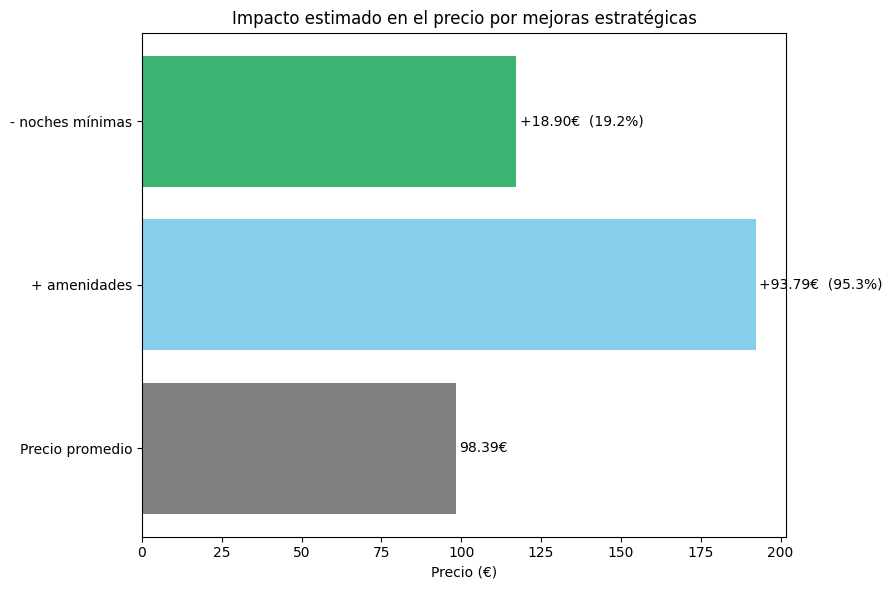

In [ ]:
import matplotlib.pyplot as plt

# Asegurarnos de tener los valores
if 'precio_referencia' in locals():
    # Precios estimados
    precio_base = precio_referencia
    precio_amenidades = precio_base + aumento_estimado_amenidades
    precio_min_nights = precio_base + aumento_estimado_min_nights

    # Porcentajes de aumento
    porcentaje_amenidades = factor_cambio_amenidades * 100
    porcentaje_min_nights = factor_cambio_min_nights * 100

    # Datos para graficar
    etiquetas = ["Precio promedio", "+ amenidades", "- noches mínimas"]
    precios = [precio_base, precio_amenidades, precio_min_nights]
    aumentos = [0, aumento_estimado_amenidades, aumento_estimado_min_nights]
    porcentajes = [0, porcentaje_amenidades, porcentaje_min_nights]

    # Crear gráfico
    plt.figure(figsize=(9, 6))
    barras = plt.barh(etiquetas, precios, color=["gray", "skyblue", "mediumseagreen"])
    plt.title("Impacto estimado en el precio por mejoras estratégicas")
    plt.xlabel("Precio (€)")

    # Agregar etiquetas con aumento y porcentaje
    for i, barra in enumerate(barras):
        valor = barra.get_width()
        if i > 0:
            texto = f"+{aumentos[i]:.2f}€  ({porcentajes[i]:.1f}%)"
            plt.text(valor + 1, barra.get_y() + barra.get_height() / 2, texto, va="center")
        else:
            plt.text(valor + 1, barra.get_y() + barra.get_height() / 2, f"{valor:.2f}€", va="center")

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ El precio de referencia no está disponible para graficar.")


📊 Cambio en log_price por cada amenidad agregada:
- kw_tv: 0.2342
- kw_air conditioning: 0.1686
- kw_heating: 0.0723
- kw_essentials: 0.0626
- kw_coffee maker: 0.0547
- kw_hair dryer: 0.0771

🔧 Cambio total estimado en log_price por amenidades: 0.6695

🔧 Cambio estimado en log_price al reducir 'log_minimum_nights_avg_ntm' en 1 unidad log: 0.1757

⚠️ Usando precio promedio convertido desde log_price: 98.39€

📈 Estimación impacto por amenidades: +93.79€ (95.3%)
📈 Estimación impacto por ↓ noches mínimas: +18.90€ (19.2%)


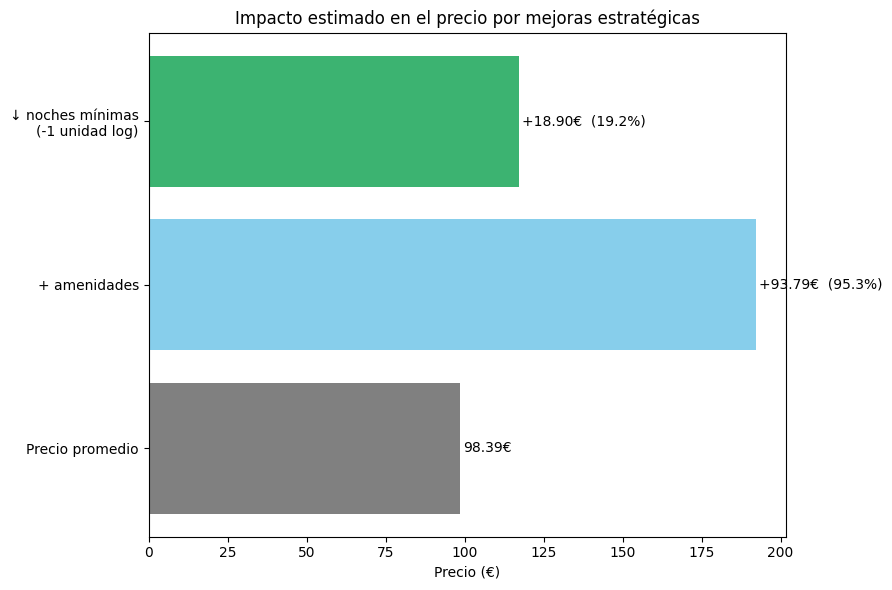

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Obtener los coeficientes del modelo de regresión lineal
coeficientes_sm = modelo_sm.params

# Amenidades para simular
amenidades_a_agregar = [
    "kw_tv",
    "kw_air conditioning",
    "kw_heating",
    "kw_essentials",
    "kw_coffee maker",
    "kw_hair dryer"
]

# Calcular el cambio total en log_price por amenidades
cambio_log_price_amenidades = 0
print("📊 Cambio en log_price por cada amenidad agregada:")
for amenidad in amenidades_a_agregar:
    coef = coeficientes_sm.get(amenidad, 0)
    print(f"- {amenidad}: {coef:.4f}")
    cambio_log_price_amenidades += coef

print(f"\n🔧 Cambio total estimado en log_price por amenidades: {cambio_log_price_amenidades:.4f}")

# Cambio en log_price por reducir noches mínimas en 1 unidad logarítmica
coef_min_nights = coeficientes_sm.get('log_minimum_nights_avg_ntm', 0)
cambio_log_price_min_nights = -coef_min_nights
print(f"\n🔧 Cambio estimado en log_price al reducir 'log_minimum_nights_avg_ntm' en 1 unidad log: {cambio_log_price_min_nights:.4f}")

# Obtener precio de referencia
try:
    precio_referencia = listings_for_plotting["price"].dropna().mean()
    print(f"\n💰 Precio promedio original usado: {precio_referencia:.2f}€")
except:
    precio_referencia = np.expm1(listings_filtrado["log_price"].dropna().mean())
    print(f"\n⚠️ Usando precio promedio convertido desde log_price: {precio_referencia:.2f}€")

# Interpretar cambios en escala original
factor_cambio_amenidades = np.expm1(cambio_log_price_amenidades)
factor_cambio_min_nights = np.expm1(cambio_log_price_min_nights)

aumento_amenidades = precio_referencia * factor_cambio_amenidades
aumento_min_nights = precio_referencia * factor_cambio_min_nights

print(f"\n📈 Estimación impacto por amenidades: +{aumento_amenidades:.2f}€ ({factor_cambio_amenidades*100:.1f}%)")
print(f"📈 Estimación impacto por ↓ noches mínimas: +{aumento_min_nights:.2f}€ ({factor_cambio_min_nights*100:.1f}%)")

# ================================
# VISUALIZACIÓN
# ================================
etiquetas = [
    "Precio promedio",
    "+ amenidades",
    "↓ noches mínimas\n(-1 unidad log)"
]
precios = [
    precio_referencia,
    precio_referencia + aumento_amenidades,
    precio_referencia + aumento_min_nights
]
aumentos = [0, aumento_amenidades, aumento_min_nights]
porcentajes = [0, factor_cambio_amenidades * 100, factor_cambio_min_nights * 100]

plt.figure(figsize=(9, 6))
barras = plt.barh(etiquetas, precios, color=["gray", "skyblue", "mediumseagreen"])
plt.title("Impacto estimado en el precio por mejoras estratégicas")
plt.xlabel("Precio (€)")

for i, barra in enumerate(barras):
    valor = barra.get_width()
    if i == 0:
        plt.text(valor + 1, barra.get_y() + barra.get_height()/2, f"{valor:.2f}€", va="center")
    else:
        texto = f"+{aumentos[i]:.2f}€  ({porcentajes[i]:.1f}%)"
        plt.text(valor + 1, barra.get_y() + barra.get_height()/2, texto, va="center")

plt.tight_layout()
plt.show()


Impacto de las Amenidades (subconjunto): Este subconjunto de amenidades parece tener un impacto aún más sustancial en el precio según este modelo lineal. Para los hosts, enfocarse en proporcionar estas amenidades podría ser una estrategia más efectiva para justificar precios más altos.
Impacto de las Noches Mínimas: La reducción del número promedio de noches mínimas sigue siendo un factor asociado a un precio por noche más alto.
Esto último es cicunstancial ya que le precio se divide por el numero de noches

Top 5 Correlations with estimated_occupancy_l365d:
number_of_reviews_ltm      0.619401
estimated_revenue_l365d    0.616235
number_of_reviews_ly       0.609975
number_of_reviews          0.540076
reviews_per_month          0.474154
Name: estimated_occupancy_l365d, dtype: float64


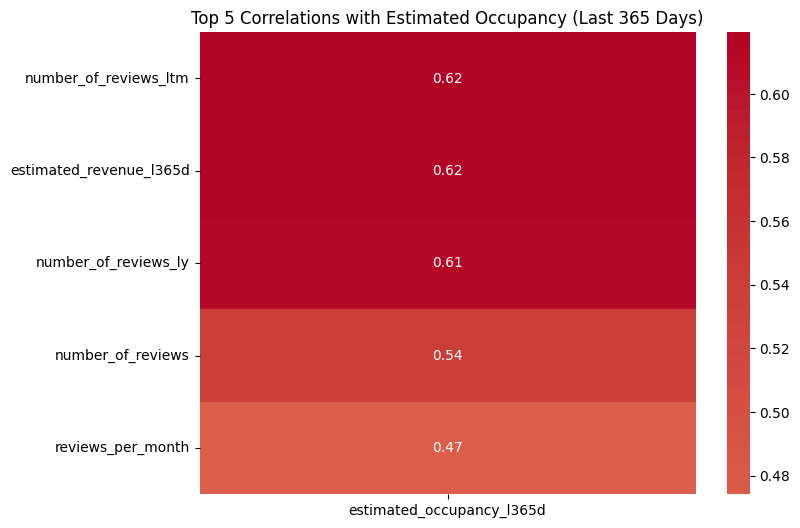

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns from the original listings DataFrame
numeric_listings = listings.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_listings.corr()

# Get the correlations with 'estimated_occupancy_l365d'
occupancy_correlations = correlation_matrix['estimated_occupancy_l365d'].sort_values(ascending=False)

# Remove the correlation of 'estimated_occupancy_l365d' with itself
occupancy_correlations = occupancy_correlations.drop('estimated_occupancy_l365d')

# Select the top 5 correlations
top_5_occupancy_correlations = occupancy_correlations.head(5)

# Print the top 5 correlations
print("Top 5 Correlations with estimated_occupancy_l365d:")
print(top_5_occupancy_correlations)

# Visualize the top 5 correlations with a heatmap
plt.figure(figsize=(8, 6)) # Adjusted figure size for fewer variables
sns.heatmap(top_5_occupancy_correlations.to_frame(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Top 5 Correlations with Estimated Occupancy (Last 365 Days)")
plt.show()

# Task
Analyze the "number of reviews ltm" column in the dataframe, then build a model to predict the increase in "estimated occupancy" based on an increase in "number of reviews ltm".

## Analyze `number of reviews ltm`

### Subtask:
Explore the data in the `number_of_reviews_ltm` column, including checking for missing values, unique values, and basic statistics.


**Reasoning**:
Explore the `number_of_reviews_ltm` column by checking for missing values, unique values, and basic statistics.



In [ ]:
# Check for missing values and calculate the percentage
missing_reviews_ltm = listings['number_of_reviews_ltm'].isnull().sum()
total_rows = len(listings)
percentage_missing_reviews_ltm = (missing_reviews_ltm / total_rows) * 100

print(f"Number of missing values in 'number_of_reviews_ltm': {missing_reviews_ltm}")
print(f"Percentage of missing values in 'number_of_reviews_ltm': {percentage_missing_reviews_ltm:.2f}%")

# Print the number of unique values
unique_reviews_ltm = listings['number_of_reviews_ltm'].nunique()
print(f"\nNumber of unique values in 'number_of_reviews_ltm': {unique_reviews_ltm}")

# Print basic statistics
print("\nBasic statistics for 'number_of_reviews_ltm':")
print(listings['number_of_reviews_ltm'].describe())

Number of missing values in 'number_of_reviews_ltm': 0
Percentage of missing values in 'number_of_reviews_ltm': 0.00%

Number of unique values in 'number_of_reviews_ltm': 181

Basic statistics for 'number_of_reviews_ltm':
count    19422.000000
mean        11.749923
std         24.279234
min          0.000000
25%          0.000000
50%          2.000000
75%         15.000000
max       1239.000000
Name: number_of_reviews_ltm, dtype: float64


In [ ]:
# Check for missing values and calculate the percentage
missing_reviews_ltm = listings['number_of_reviews_ltm'].isnull().sum()
total_rows = len(listings)
percentage_missing_reviews_ltm = (missing_reviews_ltm / total_rows) * 100

print(f"Number of missing values in 'number_of_reviews_ltm': {missing_reviews_ltm}")
print(f"Percentage of missing values in 'number_of_reviews_ltm': {percentage_missing_reviews_ltm:.2f}%")

# Print the number of unique values
unique_reviews_ltm = listings['number_of_reviews_ltm'].nunique()
print(f"\nNumber of unique values in 'number_of_reviews_ltm': {unique_reviews_ltm}")

# Print basic statistics
print("\nBasic statistics for 'number_of_reviews_ltm':")
print(listings['number_of_reviews_ltm'].describe())

Number of missing values in 'number_of_reviews_ltm': 0
Percentage of missing values in 'number_of_reviews_ltm': 0.00%

Number of unique values in 'number_of_reviews_ltm': 181

Basic statistics for 'number_of_reviews_ltm':
count    19422.000000
mean        11.749923
std         24.279234
min          0.000000
25%          0.000000
50%          2.000000
75%         15.000000
max       1239.000000
Name: number_of_reviews_ltm, dtype: float64


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Select the relevant columns
df_reviews_occupancy = listings[['number_of_reviews_ltm', 'estimated_occupancy_l365d']].copy()

# Check for and handle missing values in the selected columns
print("Missing values before dropping:")
print(df_reviews_occupancy.isnull().sum())

df_reviews_occupancy = df_reviews_occupancy.dropna(
    subset=['number_of_reviews_ltm', 'estimated_occupancy_l365d']
)

print("\nMissing values after dropping:")
print(df_reviews_occupancy.isnull().sum())

# Define X and y
X = df_reviews_occupancy[['number_of_reviews_ltm']] # X as DataFrame
y = df_reviews_occupancy['estimated_occupancy_l365d'] # y as Series

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nData prepared and split:")
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Missing values before dropping:
number_of_reviews_ltm        0
estimated_occupancy_l365d    0
dtype: int64

Missing values after dropping:
number_of_reviews_ltm        0
estimated_occupancy_l365d    0
dtype: int64

Data prepared and split:
Shape of X_train: (15537, 1)
Shape of X_test: (3885, 1)
Shape of y_train: (15537,)
Shape of y_test: (3885,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate and train the RandomForestRegressor model
model_reviews_occupancy = RandomForestRegressor(random_state=42)
model_reviews_occupancy.fit(X_train, y_train)

print("RandomForestRegressor model for predicting estimated_occupancy_l365d based on number_of_reviews_ltm trained successfully.")

RandomForestRegressor model for predicting estimated_occupancy_l365d based on number_of_reviews_ltm trained successfully.


In [ ]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Make predictions on the test set
y_pred = model_reviews_occupancy.predict(X_test)

# Calculate R² score
r2 = r2_score(y_test, y_pred)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Print the evaluation metrics
print(f"Model Evaluation on Test Set:")
print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.2f}")

Model Evaluation on Test Set:
R² Score: 0.779
RMSE: 45.46


In [ ]:
import numpy as np
import pandas as pd

# Calculate the average number of reviews in the last 12 months from the test set
average_reviews_ltm = X_test["number_of_reviews_ltm"].mean()

# Define the increase in reviews you want to simulate
increase_in_reviews = 10 # Example: simulate an increase of 10 reviews

# Create two data points for prediction:
# 1. The average number of reviews
# 2. The average number of reviews + the defined increase
# These need to be in the same format as X_test (a DataFrame with one column)
prediction_points_reviews = pd.DataFrame({
    "number_of_reviews_ltm": [average_reviews_ltm, average_reviews_ltm + increase_in_reviews]
})

# Make predictions using the trained model
predicted_occupancy_reviews = model_reviews_occupancy.predict(prediction_points_reviews)

# The predicted occupancy for the average number of reviews
occupancy_at_average_reviews = predicted_occupancy_reviews[0]

# The predicted occupancy for the average number of reviews + increase
occupancy_at_increased_reviews = predicted_occupancy_reviews[1]

# Calculate the estimated increase in occupancy
estimated_increase_occupancy = occupancy_at_increased_reviews - occupancy_at_average_reviews

print(f"Average number of reviews in the last 12 months in the test set: {average_reviews_ltm:.2f}")
print(f"Estimated occupancy at average reviews: {occupancy_at_average_reviews:.2f}")
print(f"Estimated occupancy at average reviews + {increase_in_reviews}: {occupancy_at_increased_reviews:.2f}")
print(f"\nEstimated increase in estimated occupancy for an increase of {increase_in_reviews} reviews in the last 12 months: {estimated_increase_occupancy:.2f}")

Average number of reviews in the last 12 months in the test set: 11.73
Estimated occupancy at average reviews: 96.11
Estimated occupancy at average reviews + 10: 148.85

Estimated increase in estimated occupancy for an increase of 10 reviews in the last 12 months: 52.74


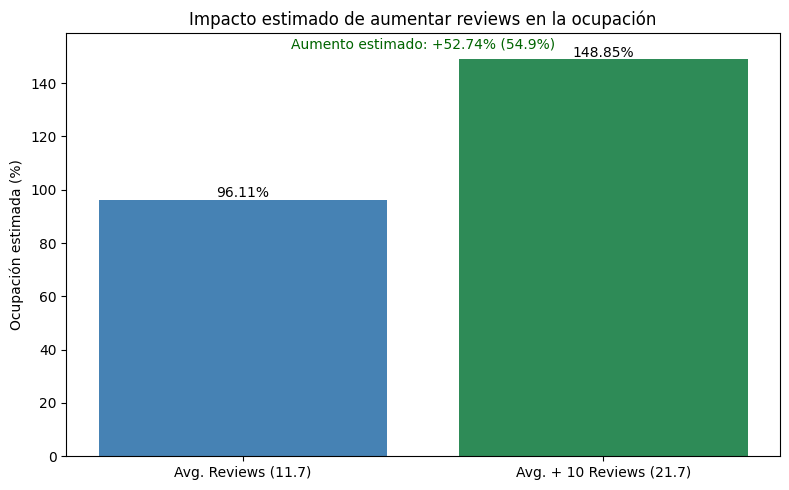

In [ ]:
import matplotlib.pyplot as plt

# Datos para graficar
labels = [
    f"Avg. Reviews ({average_reviews_ltm:.1f})",
    f"Avg. + {increase_in_reviews} Reviews ({average_reviews_ltm + increase_in_reviews:.1f})"
]
occupancies = [occupancy_at_average_reviews, occupancy_at_increased_reviews]
incremento_porcentaje = estimated_increase_occupancy / occupancy_at_average_reviews * 100

# Crear gráfico
plt.figure(figsize=(8, 5))
barras = plt.bar(labels, occupancies, color=["steelblue", "seagreen"])
plt.title("Impacto estimado de aumentar reviews en la ocupación")
plt.ylabel("Ocupación estimada (%)")

# Añadir etiquetas con valores
for i, barra in enumerate(barras):
    valor = barra.get_height()
    plt.text(barra.get_x() + barra.get_width() / 2, valor + 1, f"{valor:.2f}%", ha="center")

# Mostrar incremento porcentual
plt.text(0.5, max(occupancies) + 4,
         f"Aumento estimado: +{estimated_increase_occupancy:.2f}% ({incremento_porcentaje:.1f}%)",
         ha="center", fontsize=10, color="darkgreen")

plt.ylim(0, max(occupancies) + 10)
plt.tight_layout()
plt.show()


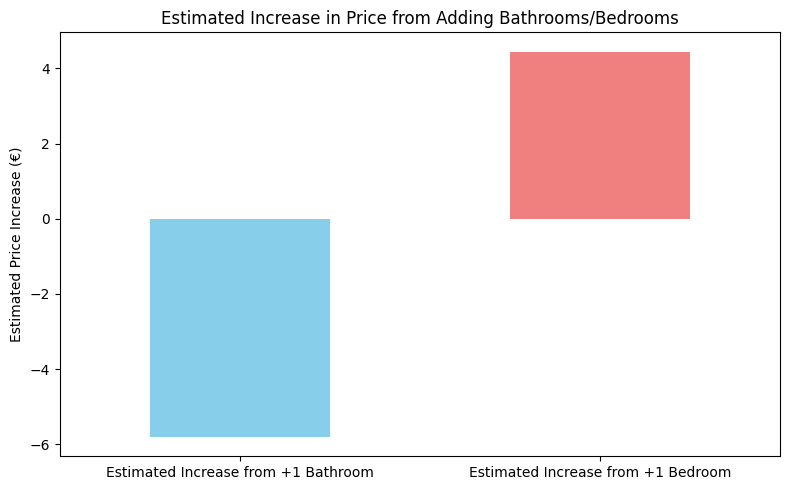

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Estimated increases calculated in the previous cell (assuming they are available)
# If the previous cell was not run, these variables would be undefined.
# To make this cell runnable independently after the model training,
# we would need to re-calculate them or ensure the previous cell was executed.

# Assuming 'aumento_estimado_bathrooms' and 'aumento_estimado_bedrooms' are available
# from the execution of cell 'bb033a9b'.

# Create a pandas Series or DataFrame for plotting
impact_data = pd.Series({
    "Estimated Increase from +1 Bathroom": aumento_estimado_bathrooms,
    "Estimated Increase from +1 Bedroom": aumento_estimado_bedrooms
})

# Create the bar chart
plt.figure(figsize=(8, 5))
impact_data.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title("Estimated Increase in Price from Adding Bathrooms/Bedrooms")
plt.ylabel("Estimated Price Increase (€)")
plt.xticks(rotation=0) # Keep labels horizontal
plt.tight_layout()
plt.show()

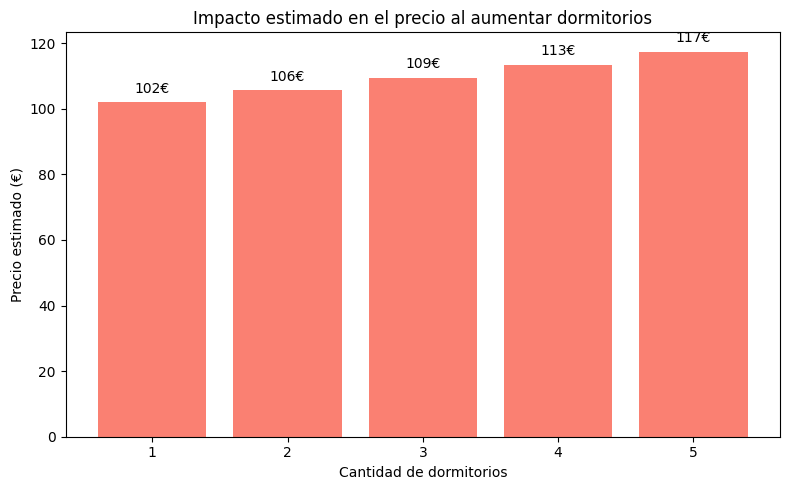

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parámetros estimados
coef_bedrooms = coeficientes_sm.get('bedrooms', 0)
precio_base = precio_referencia  # Ya calculado previamente

# Rango de dormitorios a simular
rango_dormitorios = list(range(1, 6))  # Por ejemplo: de 1 a 5 dormitorios

# Calcular log_price simulado para cada número de dormitorios
precios_estimados = []
for n in rango_dormitorios:
    cambio_log_price = coef_bedrooms * n
    factor_cambio = np.expm1(cambio_log_price)
    precio_estimado = precio_base * (1 + factor_cambio)
    precios_estimados.append(precio_estimado)

# Crear gráfico
plt.figure(figsize=(8, 5))
plt.bar(rango_dormitorios, precios_estimados, color="salmon")
plt.title("Impacto estimado en el precio al aumentar dormitorios")
plt.xlabel("Cantidad de dormitorios")
plt.ylabel("Precio estimado (€)")

# Añadir etiquetas
for i, valor in enumerate(precios_estimados):
    plt.text(rango_dormitorios[i], valor + 3, f"{valor:.0f}€", ha="center")

plt.xticks(rango_dormitorios)
plt.tight_layout()
plt.show()


/tmp/ipython-input-68-3956718646.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_barrios_precio["mean"], y=top_10_barrios_precio.index, palette="viridis")
/tmp/ipython-input-68-3956718646.py:16: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


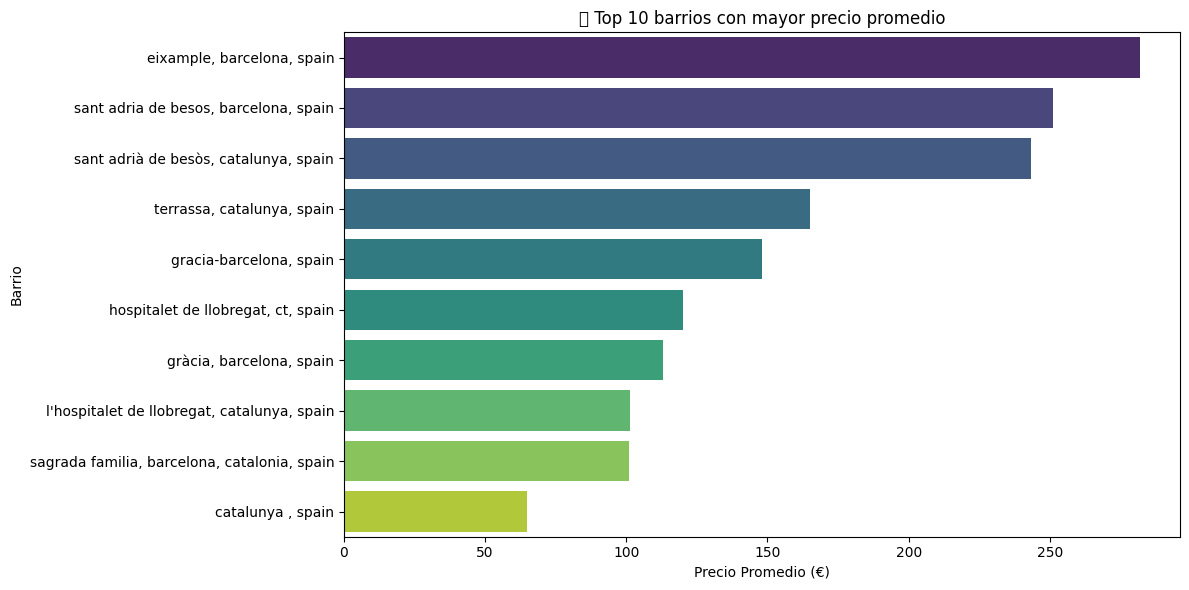

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'resumen' DataFrame is available from the previous step
# If not, the previous cell would need to be re-executed or the data reloaded/processed

# Select the top 10 neighborhoods by mean price
top_10_barrios_precio = resumen.head(10)

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_barrios_precio["mean"], y=top_10_barrios_precio.index, palette="viridis")
plt.title("🔝 Top 10 barrios con mayor precio promedio")
plt.xlabel("Precio Promedio (€)")
plt.ylabel("Barrio")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Leer archivo con columnas necesarias
# Cambiado a 'neighbourhood_group_cleansed'
df = pd.read_csv("listings.csv.gz", compression="gzip", usecols=["neighbourhood_group_cleansed", "price"])

# Crear copia para limpieza
df_limpio = df.copy()

# Eliminar nulos
# Asegurarse de que la columna correcta se usa para eliminar nulos
df_limpio = df_limpio.dropna(subset=["neighbourhood_group_cleansed", "price"])

# Normalizar (puede que no sea tan necesario para neighbourhood_group_cleansed si ya está limpio,
# pero lo mantenemos por si acaso)
df_limpio["neighbourhood_group_cleansed"] = df_limpio["neighbourhood_group_cleansed"].str.strip().str.lower()

# Lista de valores exactos a eliminar (ajustada si es necesario para los nuevos valores)
# Mantendremos esta lista por si hay valores no deseados, aunque puede que no aplique igual
valores_excluir = {
    "*,barcelona,spain",
    "барселона, каталония, spain ",
    "barcelona, spain",
    "., barcelona, spain",
    "барселона","барселона, каталония, spain","*, barcelona, spain","3-1, barcelona, spain",
    "каталония",
    "spain",
    "барселона, barcelona, spain"
}

# Eliminar vecindarios que están en la lista o que empiezan por "barcelona" (ajustado)
# Esta lógica podría no ser necesaria para neighbourhood_group_cleansed si los valores son limpios
# La comentamos, pero la dejamos por si acaso se necesita una exclusión similar.
# df_limpio = df_limpio[
#     ~df_limpio["neighbourhood_group_cleansed"].isin(valores_excluir) #&
    # ~df_limpio["neighbourhood_group_cleansed"].str.lower().str.startswith("barcelona") # Use .str.lower() before .str.startswith()
# ]

# Limpiar columna de precio
df_limpio["price"] = df_limpio["price"].replace("[\$,]", "", regex=True).astype(float)

# Agrupar por grupo de vecindario y calcular estadísticas
resumen = df_limpio.groupby("neighbourhood_group_cleansed")["price"].agg(["count", "mean", "median"]).sort_values(by="mean", ascending=False)

# Mostrar top 10 grupos de vecindario por precio promedio
print("🔝 Top grupos de vecindario con mayor precio promedio:")
print(resumen.head(10)) # Mostramos los top 10, aunque puede haber menos

🔝 Top grupos de vecindario con mayor precio promedio:
                              count        mean  median
neighbourhood_group_cleansed                           
eixample                       5605  191.945049   148.0
sant martí                     1428  187.085434   123.0
sants-montjuïc                 1587  163.560807   100.0
gràcia                         1319  151.435936   125.0
les corts                       317  135.813880   130.0
sarrià-sant gervasi             912  135.205044   118.0
ciutat vella                   3322  125.817881    85.0
sant andreu                     218  124.481651    63.0
horta-guinardó                  410  103.407317    69.5
nou barris                      155   71.283871    55.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas

# Ensure 'neighbourhood_summary_map' DataFrame is available from the map generation step.
# If that cell was not run, this will cause an error.
# Assuming the previous map generation cell (26fe24aa) was run and created this DataFrame.

if 'neighbourhood_summary_map' in locals():
    # Sort the summary data by mean price in descending order
    sorted_neighbourhood_prices = neighbourhood_summary_map.sort_values(by='mean_price', ascending=False)

    # Select only the neighbourhood and mean_price columns for the table
    price_table_data = sorted_neighbourhood_prices[['neighbourhood', 'mean_price']]

    # Rename the columns for clarity
    price_table_data = price_table_data.rename(columns={
        'neighbourhood': 'Barrio',
        'mean_price': 'Precio Promedio (€)'
    })

    # Create the bar plot
    plt.figure(figsize=(12, 6))
    # Use the 'Barrio' column for the y-axis and 'Precio Promedio (€)' for the x-axis
    # Use a color palette to assign a different color to each bar
    sns.barplot(x=price_table_data["Precio Promedio (€)"], y=price_table_data["Barrio"], palette="viridis") # Using 'viridis' palette

    plt.title("🔝 Precio Promedio por Barrio (Top 7) con Color por Barrio")
    plt.xlabel("Precio Promedio (€)")
    plt.ylabel("Barrio")
    plt.tight_layout()
    plt.show()
else:
    print("Error: El DataFrame 'neighbourhood_summary_map' no fue encontrado.")
    print("Por favor, asegúrate de ejecutar la celda que genera el mapa antes de ejecutar esta celda.")

Error: El DataFrame 'neighbourhood_summary_map' no fue encontrado.
Por favor, asegúrate de ejecutar la celda que genera el mapa antes de ejecutar esta celda.


/tmp/ipython-input-71-565527167.py:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model_improved[col].fillna(median_val, inplace=True)
/tmp/ipython-input-71-565527167.py:48: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

📊 Evaluación del modelo de Random Forest mejorado:
🔹 R² score: 0.082
🔹 RMSE: 255.60


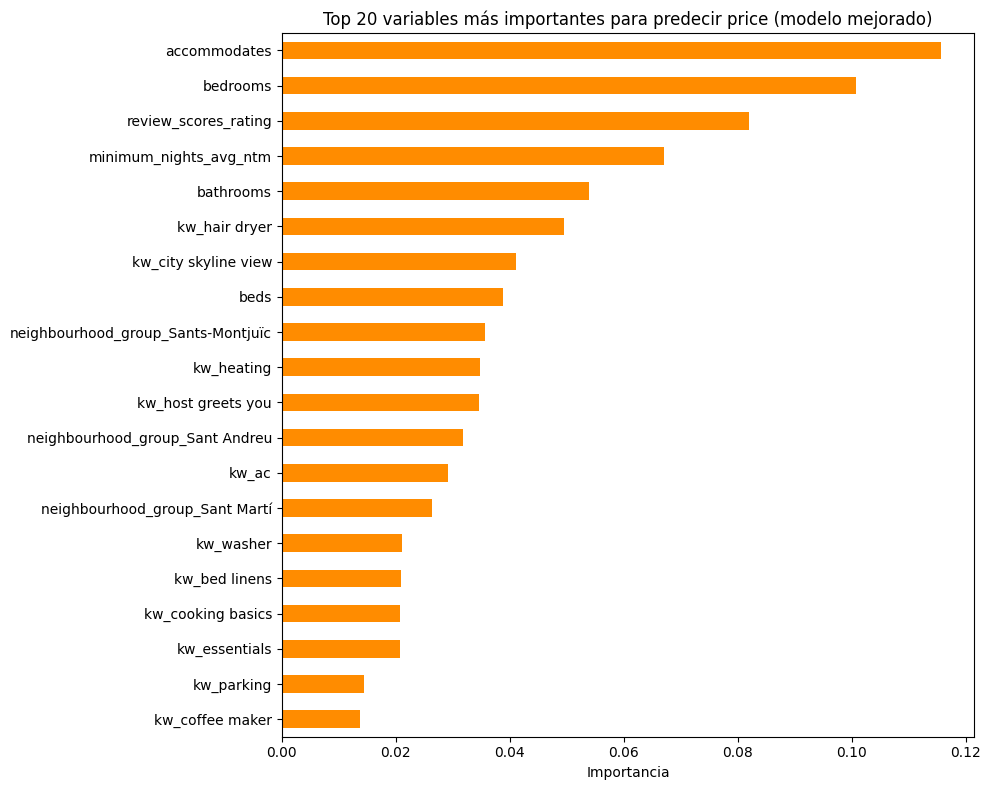

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# ================================
# 1. Preparar los datos
# ================================
# Cargar las columnas necesarias, incluyendo la categórica
columns_to_load = [
    "price", "accommodates", "bathrooms", "bedrooms", "beds",
    "minimum_nights_avg_ntm", "review_scores_rating",
    "host_is_superhost", "has_availability", "neighbourhood_group_cleansed"
]

# Add the amenity columns that were created earlier
amenity_columns = [col for col in listings.columns if col.startswith("kw_")]
columns_to_load.extend(amenity_columns)

# Ensure unique columns
columns_to_load = list(set(columns_to_load))


# Load the data using the 'listings' DataFrame which should contain the amenity columns already
df_model_improved = listings[columns_to_load].copy()

# Handle NaNs in the target variable ('price')
df_model_improved.dropna(subset=["price"], inplace=True)

# Handle NaNs in other potentially important numerical features
# Fill numerical NaNs with median or mean, or consider more sophisticated imputation
numerical_cols_for_imputation = [
    "accommodates", "bathrooms", "bedrooms", "beds",
    "minimum_nights_avg_ntm", "review_scores_rating",
    "host_is_superhost", "has_availability" # host_is_superhost and has_availability already handled, but good practice
]

for col in numerical_cols_for_imputation:
    if col in df_model_improved.columns:
        # Using median for imputation
        median_val = df_model_improved[col].median()
        df_model_improved[col].fillna(median_val, inplace=True)


# Handle NaNs in the categorical variable
df_model_improved["neighbourhood_group_cleansed"].fillna("Unknown", inplace=True) # Or use mode imputation


# ================================
# 2. Codificación de variables categóricas (One-Hot Encoding)
# ================================
df_model_improved = pd.get_dummies(
    df_model_improved,
    columns=["neighbourhood_group_cleansed"],
    dummy_na=False, # Corrected parameter name and value
    prefix="neighbourhood_group"
)


# ================================
# 3. Definir variables X e y
# ================================
X = df_model_improved.drop(columns="price")
y = df_model_improved["price"]

# Ensure no infinite values introduced by dummy encoding or other processes
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.dropna(inplace=True)
y = y.loc[X.index] # Align y after dropping rows in X


# ================================
# 4. División en entrenamiento y prueba
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 5. Entrenamiento del modelo
# ================================
modelo_mejorado = RandomForestRegressor(random_state=42)
modelo_mejorado.fit(X_train, y_train)

# ================================
# 6. Evaluación del modelo
# ================================
y_pred_mejorado = modelo_mejorado.predict(X_test)

print("📊 Evaluación del modelo de Random Forest mejorado:")
print(f"🔹 R² score: {r2_score(y_test, y_pred_mejorado):.3f}")
print(f"🔹 RMSE: {mean_squared_error(y_test, y_pred_mejorado)**0.5:.2f}")

# ================================
# 7. Importancia de Variables
# ================================
# Obtener las 20 variables más importantes (para incluir algunos grupos de vecindario si son relevantes)
importancia_mejorada = pd.Series(modelo_mejorado.feature_importances_, index=X.columns)
top_20_mejorado = importancia_mejorada.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
top_20_mejorado.sort_values().plot(kind='barh', color='darkorange')
plt.title("Top 20 variables más importantes para predecir price (modelo mejorado)")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

In [ ]:
print("Columnas del DataFrame listings_filtrado:\n")
for i, col in enumerate(listings_filtrado.columns, start=1):
    print(f"{i:02d}. {col}")

Columnas del DataFrame listings_filtrado:

01. id
02. host_since
03. host_location
04. host_about
05. host_response_time
06. host_response_rate
07. host_acceptance_rate
08. host_is_superhost
09. host_thumbnail_url
10. host_picture_url
11. host_neighbourhood
12. host_listings_count
13. host_total_listings_count
14. host_verifications
15. host_has_profile_pic
16. host_identity_verified
17. neighbourhood
18. neighbourhood_cleansed
19. neighbourhood_group_cleansed
20. latitude
21. longitude
22. property_type
23. room_type
24. accommodates
25. bathrooms
26. bathrooms_text
27. bedrooms
28. amenities
29. minimum_nights
30. maximum_nights
31. minimum_minimum_nights
32. maximum_minimum_nights
33. minimum_maximum_nights
34. maximum_maximum_nights
35. maximum_nights_avg_ntm
36. calendar_updated
37. has_availability
38. availability_30
39. availability_60
40. availability_90
41. availability_365
42. calendar_last_scraped
43. number_of_reviews
44. number_of_reviews_ltm
45. number_of_reviews_l30d
46

In [ ]:
import numpy as np

# Obtener los coeficientes del modelo de regresión lineal
# Asegurarse de que modelo_sm está disponible (fue entrenado en la celda anterior)
if 'modelo_sm' not in locals():
    print("Error: El modelo de regresión lineal (modelo_sm) no está disponible. Por favor, ejecuta la celda donde se entrena.")
else:
    coeficientes_sm = modelo_sm.params

    # Identificar los coeficientes de las variables 'kw_'
    coeficientes_amenidades = coeficientes_sm.filter(regex='^kw_')

    # Calcular el cambio total en log_price al añadir todas estas amenidades
    # Asumimos que el estado actual es 0 para todas estas amenidades y cambia a 1
    # El cambio total en log_price es la suma de los coeficientes
    cambio_log_price_total_amenidades = coeficientes_amenidades.sum()

    print(f"Cambio total estimado en log_price al añadir todas las amenidades (variables 'kw_'): {cambio_log_price_total_amenidades:.4f}")

    # ==============================================================
    # Interpretar el cambio en la escala original del precio
    # ==============================================================
    # Necesitamos un precio de referencia para estimar el aumento absoluto.
    # Usaremos el precio promedio de los datos que entraron al modelo statsmodels (df_model_cleaned).
    # df_model_cleaned contiene log_price, no el price original.
    # Para ser consistentes, usaremos listings_filtrado['price'] que es el DataFrame antes de la trans. log
    # y después de la limpieza de outliers (IQR 1).
    # La variable listings_for_plotting en cell 37a6c502 fue usada para esto.
    # Si listings_for_plotting no existe, calculamos el promedio de log_price y lo convertimos a escala original.

    try:
        # Intentar usar la variable global listings_for_plotting si existe y tiene 'price'
        # This variable was not explicitly kept in the notebook state, let's use df_final and inverse log
        # Calculate the mean of the *original* price from df_model_cleaned (before log transform)
        # We don't have the original price in df_model_cleaned. We only have log_price.
        # Let's use the average of the original 'price' column from the listings DataFrame
        # AFTER the initial price cleaning in cell a338163f-1dc9-4258-9e8e-193072c80bb6
        # This price was before the IQR outlier removal with a multiplier of 1.5,
        # but it's more representative of the original scale before log transform.
        # A more precise approach would be to re-calculate the mean of 'price'
        # on the rows of 'listings' that correspond to the final 'X_sm' index,
        # before the log transform.

        # Let's use the mean of the original 'price' column from the initial listings DataFrame after cleaning price
        # Cell a338163f-1dc9-4258-9e8e-193072c80bb6 cleaned the price column.
        # We need the 'price' column from 'listings' AFTER that cell ran.
        # Let's calculate the mean of the 'price' column in the current 'listings' DataFrame,
        # but only for the rows that are *also* present in the final X_sm used for the model.
        # This ensures the reference price is representative of the data the model saw.

        # Get the indices of the data used for the statsmodels OLS model
        indices_usados_en_modelo_sm = X_sm.index

        # Calculate the mean of the original 'price' column from the 'listings' DataFrame,
        # filtered to include only the rows used in the statsmodels model.
        # Ensure 'price' column exists and is numeric after cleaning.
        if 'price' in listings.columns and pd.api.types.is_numeric_dtype(listings['price']):
             precio_referencia = listings.loc[indices_usados_en_modelo_sm, 'price'].mean()
             print(f"\nUsando un precio de referencia promedio de {precio_referencia:.2f}€ (basado en los datos modelados):")

             # Calcular el factor de cambio en el precio original
             # exp(cambio_log_price) - 1 es el cambio fraccional
             factor_cambio_total_amenidades = np.expm1(cambio_log_price_total_amenidades) # exp(c) - 1

             # Calcular el aumento absoluto estimado en el precio original
             aumento_estimado_total_amenidades = precio_referencia * factor_cambio_total_amenidades

             print(f"Aumento absoluto estimado en el precio original al añadir todas las amenidades: ≈ {aumento_estimado_total_amenidades:.2f}€")

        else:
            print("\nAdvertencia: La columna 'price' en 'listings' no es numérica o no está disponible para calcular el precio de referencia.")
            print("No se puede estimar el aumento absoluto en la escala original del precio.")


    except NameError:
        print("\nAdvertencia: No se pudo determinar un precio de referencia representativo.")
        print("No se puede estimar el aumento absoluto en la escala original del precio.")
        print(f"El cambio estimado en log_price es: {cambio_log_price_total_amenidades:.4f}")


    print("\nNota: Esta es una estimación basada en los coeficientes del modelo lineal (OLS).")
    print("Asume que el efecto de cada amenidad se suma linealmente y que el estado inicial para todas ellas es la ausencia (valor 0).")
    print("El impacto real puede variar y puede haber interacciones entre amenidades no capturadas por la suma simple de coeficientes lineales.")

Cambio total estimado en log_price al añadir todas las amenidades (variables 'kw_'): 1.5060

Usando un precio de referencia promedio de 123.39€ (basado en los datos modelados):
Aumento absoluto estimado en el precio original al añadir todas las amenidades: ≈ 432.93€

Nota: Esta es una estimación basada en los coeficientes del modelo lineal (OLS).
Asume que el efecto de cada amenidad se suma linealmente y que el estado inicial para todas ellas es la ausencia (valor 0).
El impacto real puede variar y puede haber interacciones entre amenidades no capturadas por la suma simple de coeficientes lineales.


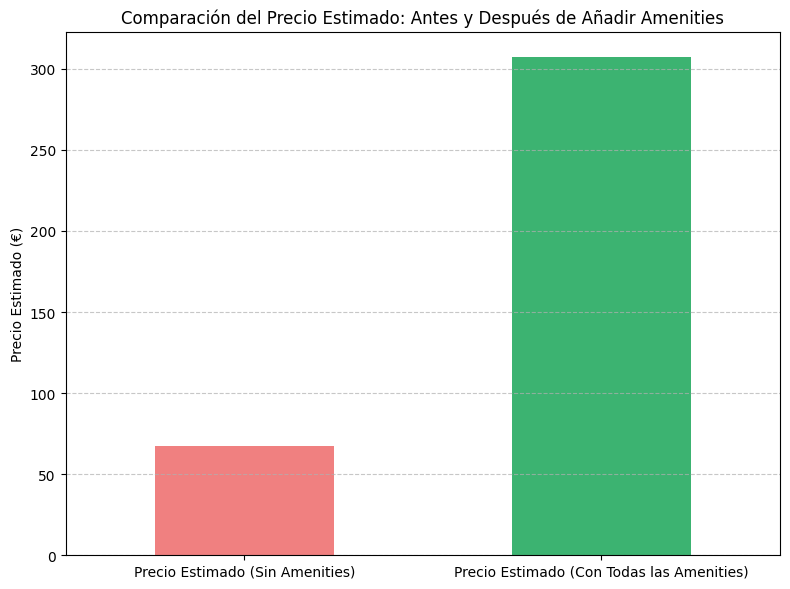

Estimación del aumento absoluto en el precio: ≈ 240.04€


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm # Import statsmodels if not already imported

# Assuming modelo_sm and X_sm are available from the previous OLS model training cell

if 'modelo_sm' not in locals() or 'X_sm' not in locals():
    print("Error: El modelo de regresión lineal (modelo_sm) o los datos (X_sm) no están disponibles.")
    print("Por favor, ejecuta la celda donde se entrena el modelo OLS.")
else:
    # 1. Crear un punto de referencia (por ejemplo, usando los valores promedio de las características)
    # Excluir la constante 'const' si existe en X_sm para el cálculo del promedio
    X_sm_features = X_sm.drop(columns='const') if 'const' in X_sm.columns else X_sm
    punto_referencia = X_sm_features.mean()

    # 2. Crear dos escenarios para la predicción:
    # Escenario 1: Sin amenidades (variables kw_ = 0)
    punto_referencia_sin_amenities = punto_referencia.copy()
    for col in punto_referencia_sin_amenities.index:
        if col.startswith('kw_'):
            punto_referencia_sin_amenities[col] = 0

    # Escenario 2: Con todas las amenidades (variables kw_ = 1)
    punto_referencia_con_amenities = punto_referencia.copy()
    for col in punto_referencia_con_amenities.index:
         if col.startswith('kw_'):
             punto_referencia_con_amenities[col] = 1


    # Asegurarse de que ambos puntos de referencia tienen el mismo orden de columnas que X_sm
    # y añadir la constante si fue excluida
    punto_referencia_sin_amenities_df = pd.DataFrame([punto_referencia_sin_amenities], columns=X_sm_features.columns)
    punto_referencia_con_amenities_df = pd.DataFrame([punto_referencia_con_amenities], columns=X_sm_features.columns)

    if 'const' in X_sm.columns:
        punto_referencia_sin_amenities_df = sm.add_constant(punto_referencia_sin_amenities_df, has_constant='add')
        punto_referencia_con_amenities_df = sm.add_constant(punto_referencia_con_amenities_df, has_constant='add')

    # Asegurarse de que el orden de las columnas coincide exactamente con X_sm
    punto_referencia_sin_amenities_df = punto_referencia_sin_amenities_df[X_sm.columns]
    punto_referencia_con_amenities_df = punto_referencia_con_amenities_df[X_sm.columns]


    # 3. Predecir el log_price para ambos escenarios usando el modelo OLS
    log_price_sin_amenities = modelo_sm.predict(punto_referencia_sin_amenities_df)[0]
    log_price_con_amenities = modelo_sm.predict(punto_referencia_con_amenities_df)[0]


    # 4. Convertir el log_price predicho a la escala original del precio
    price_sin_amenities = np.expm1(log_price_sin_amenities) # exp(log_price) - 1 for consistency with log1p
    price_con_amenities = np.expm1(log_price_con_amenities)


    # 5. Crear los datos para el gráfico de barras
    precios_estimados = pd.Series({
        "Precio Estimado (Sin Amenities)": price_sin_amenities,
        "Precio Estimado (Con Todas las Amenities)": price_con_amenities
    })

    # 6. Crear el gráfico de barras
    plt.figure(figsize=(8, 6))
    precios_estimados.plot(kind='bar', color=['lightcoral', 'mediumseagreen'])
    plt.title("Comparación del Precio Estimado: Antes y Después de Añadir Amenities")
    plt.ylabel("Precio Estimado (€)")
    plt.xticks(rotation=0) # Mantener etiquetas horizontales
    plt.grid(axis='y', linestyle='--', alpha=0.7) # Añadir cuadrícula en el eje Y
    plt.tight_layout()
    plt.show()

    # Mostrar el aumento estimado también
    aumento_estimado = price_con_amenities - price_sin_amenities
    print(f"Estimación del aumento absoluto en el precio: ≈ {aumento_estimado:.2f}€")

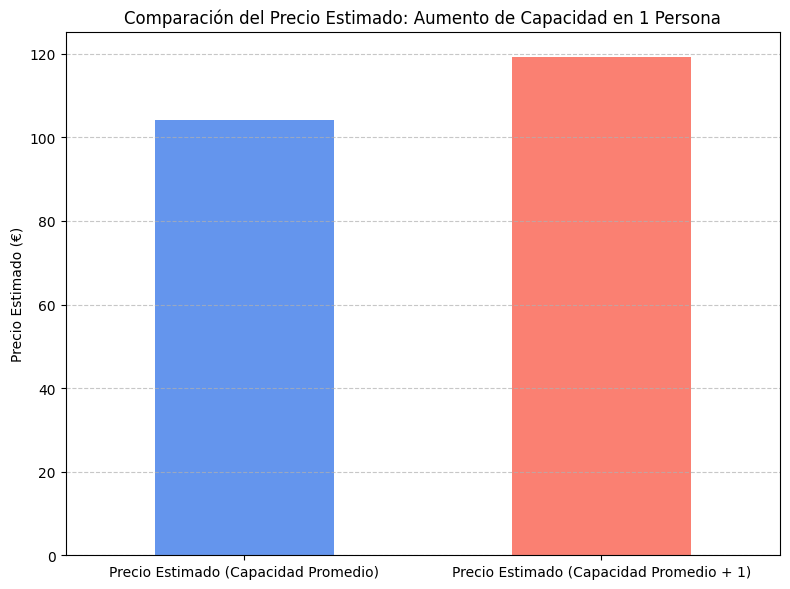

Estimación del aumento absoluto en el precio al añadir una persona a la capacidad: ≈ 15.21€


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Assuming modelo_sm and X_sm are available from the OLS model training cell

if 'modelo_sm' not in locals() or 'X_sm' not in locals():
    print("Error: El modelo de regresión lineal (modelo_sm) o los datos (X_sm) no están disponibles.")
    print("Por favor, ejecuta la celda donde se entrena el modelo OLS.")
else:
    # 1. Crear un punto de referencia (por ejemplo, usando los valores promedio de las características)
    X_sm_features = X_sm.drop(columns='const') if 'const' in X_sm.columns else X_sm
    punto_referencia = X_sm_features.mean()

    # 2. Crear dos escenarios para la predicción:
    # Escenario 1: Precio estimado en el punto de referencia (capacidad promedio)
    # Usamos el punto de referencia tal cual para esta predicción.
    punto_referencia_df = pd.DataFrame([punto_referencia], columns=X_sm_features.columns)
    if 'const' in X_sm.columns:
        punto_referencia_df = sm.add_constant(punto_referencia_df, has_constant='add')
    punto_referencia_df = punto_referencia_df[X_sm.columns] # Ensure order

    # Escenario 2: Precio estimado con capacidad + 1
    punto_referencia_accommodates_plus_1 = punto_referencia.copy()
    # Asegurarse de que 'accommodates' es numérico antes de sumar
    punto_referencia_accommodates_plus_1['accommodates'] = pd.to_numeric(punto_referencia_accommodates_plus_1['accommodates'], errors='coerce')
    if pd.notnull(punto_referencia_accommodates_plus_1['accommodates']):
         punto_referencia_accommodates_plus_1['accommodates'] += 1
    else:
        # Handle case where accommodates was NaN even in the mean (unlikely after dropna)
        punto_referencia_accommodates_plus_1['accommodates'] = 1 # or some default value

    punto_referencia_accommodates_plus_1_df = pd.DataFrame([punto_referencia_accommodates_plus_1], columns=X_sm_features.columns)
    if 'const' in X_sm.columns:
        punto_referencia_accommodates_plus_1_df = sm.add_constant(punto_referencia_accommodates_plus_1_df, has_constant='add')
    punto_referencia_accommodates_plus_1_df = punto_referencia_accommodates_plus_1_df[X_sm.columns] # Ensure order


    # 3. Predecir el log_price para ambos escenarios
    log_price_referencia = modelo_sm.predict(punto_referencia_df)[0]
    log_price_accommodates_plus_1 = modelo_sm.predict(punto_referencia_accommodates_plus_1_df)[0]

    # 4. Convertir el log_price predicho a la escala original del precio
    price_referencia = np.expm1(log_price_referencia)
    price_accommodates_plus_1 = np.expm1(log_price_accommodates_plus_1)

    # 5. Crear los datos para el gráfico de barras
    precios_estimados = pd.Series({
        "Precio Estimado (Capacidad Promedio)": price_referencia,
        "Precio Estimado (Capacidad Promedio + 1)": price_accommodates_plus_1
    })

    # 6. Crear el gráfico de barras
    plt.figure(figsize=(8, 6))
    precios_estimados.plot(kind='bar', color=['cornflowerblue', 'salmon'])
    plt.title("Comparación del Precio Estimado: Aumento de Capacidad en 1 Persona")
    plt.ylabel("Precio Estimado (€)")
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Mostrar el aumento estimado también
    aumento_estimado = price_accommodates_plus_1 - price_referencia
    print(f"Estimación del aumento absoluto en el precio al añadir una persona a la capacidad: ≈ {aumento_estimado:.2f}€")

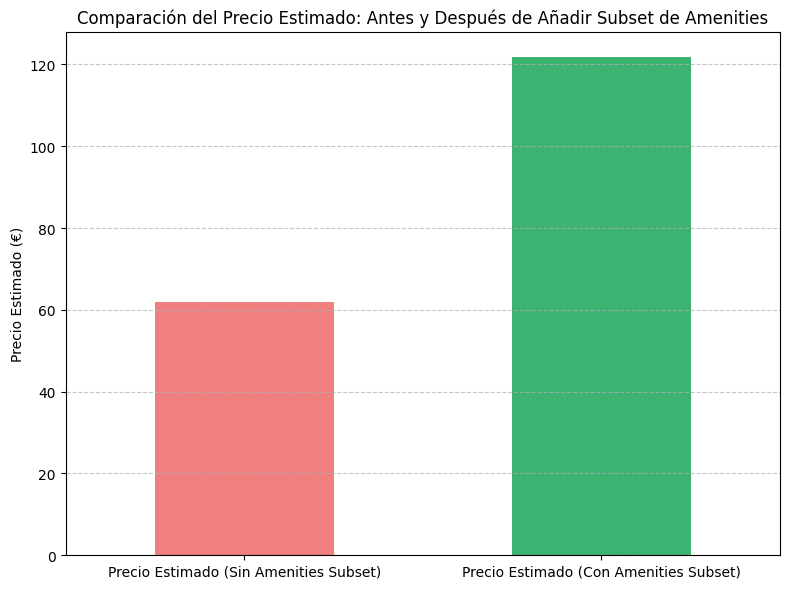

Estimación del aumento absoluto en el precio (Subset de Amenities): ≈ 59.97€


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Assuming modelo_sm and X_sm are available from the OLS model training cell

if 'modelo_sm' not in locals() or 'X_sm' not in locals():
    print("Error: El modelo de regresión lineal (modelo_sm) o los datos (X_sm) no están disponibles.")
    print("Por favor, ejecuta la celda donde se entrena el modelo OLS.")
else:
    # 1. Crear un punto de referencia (por ejemplo, usando los valores promedio de las características)
    # Excluir la constante 'const' si existe en X_sm para el cálculo del promedio
    X_sm_features = X_sm.drop(columns='const') if 'const' in X_sm.columns else X_sm
    punto_referencia = X_sm_features.mean()

    # Lista de amenidades específicas consideradas en la celda anterior (5a409e74)
    amenidades_a_agregar = [
        "kw_tv",
        "kw_air conditioning",
        # "kw_host greets you", # Eliminado
        "kw_heating",
        "kw_essentials",
        "kw_coffee maker",
        "kw_hair dryer",
        # "kw_cooking basics" # Eliminado
    ]


    # 2. Crear dos escenarios para la predicción:
    # Escenario 1: Precio estimado en el punto de referencia (sin el subconjunto específico de amenidades)
    punto_referencia_sin_subset_amenities = punto_referencia.copy()
    for col in amenidades_a_agregar:
        if col in punto_referencia_sin_subset_amenities.index:
             punto_referencia_sin_subset_amenities[col] = 0 # Set specific amenities to 0


    # Escenario 2: Precio estimado con el subconjunto específico de amenidades (variables kw_ en 1 para ese subset)
    punto_referencia_con_subset_amenities = punto_referencia.copy()
    for col in amenidades_a_agregar:
         if col in punto_referencia_con_subset_amenities.index:
             punto_referencia_con_subset_amenities[col] = 1 # Set specific amenities to 1


    # Asegurarse de que ambos puntos de referencia tienen el mismo orden de columnas que X_sm
    # y añadir la constante si fue excluida
    punto_referencia_sin_subset_amenities_df = pd.DataFrame([punto_referencia_sin_subset_amenities], columns=X_sm_features.columns)
    punto_referencia_con_subset_amenities_df = pd.DataFrame([punto_referencia_con_subset_amenities], columns=X_sm_features.columns)

    if 'const' in X_sm.columns:
        punto_referencia_sin_subset_amenities_df = sm.add_constant(punto_referencia_sin_subset_amenities_df, has_constant='add')
        punto_referencia_con_subset_amenities_df = sm.add_constant(punto_referencia_con_subset_amenities_df, has_constant='add')

    # Asegurarse de que el orden de las columnas coincide exactamente con X_sm
    punto_referencia_sin_subset_amenities_df = punto_referencia_sin_subset_amenities_df[X_sm.columns]
    punto_referencia_con_subset_amenities_df = punto_referencia_con_subset_amenities_df[X_sm.columns]


    # 3. Predecir el log_price para ambos escenarios usando el modelo OLS
    log_price_sin_subset_amenities = modelo_sm.predict(punto_referencia_sin_subset_amenities_df)[0]
    log_price_con_subset_amenities = modelo_sm.predict(punto_referencia_con_subset_amenities_df)[0]


    # 4. Convertir el log_price predicho a la escala original del precio
    price_sin_subset_amenities = np.expm1(log_price_sin_subset_amenities) # exp(log_price) - 1 for consistency with log1p
    price_con_subset_amenities = np.expm1(log_price_con_subset_amenities)


    # 5. Crear los datos para el gráfico de barras
    precios_estimados_subset_amenities = pd.Series({
        "Precio Estimado (Sin Amenities Subset)": price_sin_subset_amenities,
        "Precio Estimado (Con Amenities Subset)": price_con_subset_amenities
    })

    # 6. Crear el gráfico de barras
    plt.figure(figsize=(8, 6))
    precios_estimados_subset_amenities.plot(kind='bar', color=['lightcoral', 'mediumseagreen'])
    plt.title("Comparación del Precio Estimado: Antes y Después de Añadir Subset de Amenities")
    plt.ylabel("Precio Estimado (€)")
    plt.xticks(rotation=0) # Mantener etiquetas horizontales
    plt.grid(axis='y', linestyle='--', alpha=0.7) # Añadir cuadrícula en el eje Y
    plt.tight_layout()
    plt.show()

    # Mostrar el aumento estimado también
    aumento_estimado_subset_amenities = price_con_subset_amenities - price_sin_subset_amenities
    print(f"Estimación del aumento absoluto en el precio (Subset de Amenities): ≈ {aumento_estimado_subset_amenities:.2f}€")

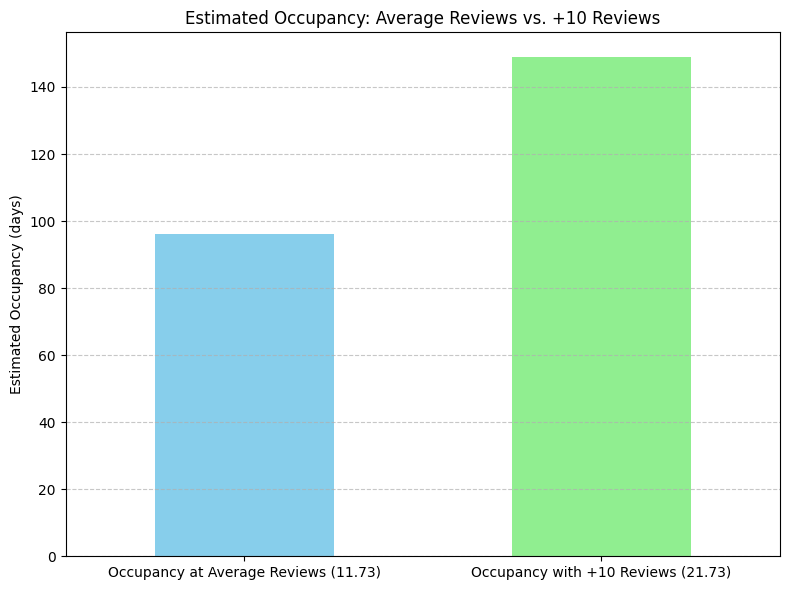

Estimated increase in estimated occupancy: 52.74


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'occupancy_at_average_reviews' and 'occupancy_at_increased_reviews' are available
# from the execution of the previous cell (b848a342).
# If not, that cell would need to be re-executed.

# Create a pandas Series for plotting
occupancy_comparison_data = pd.Series({
    f"Occupancy at Average Reviews ({average_reviews_ltm:.2f})": occupancy_at_average_reviews,
    f"Occupancy with +{increase_in_reviews} Reviews ({average_reviews_ltm + increase_in_reviews:.2f})": occupancy_at_increased_reviews
})

# Create the bar chart
plt.figure(figsize=(8, 6))
occupancy_comparison_data.plot(kind='bar', color=['skyblue', 'lightgreen'])
plt.title(f"Estimated Occupancy: Average Reviews vs. +{increase_in_reviews} Reviews")
plt.ylabel("Estimated Occupancy (days)")
plt.xticks(rotation=0) # Keep labels horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid lines on Y-axis
plt.tight_layout()
plt.show()

# Print the estimated increase again for clarity
print(f"Estimated increase in estimated occupancy: {estimated_increase_occupancy:.2f}")

# Task
Refina la limpieza de la columna `neighbourhood` en el dataframe `df_final` eliminando los valores "bcn, spain" y "catalunya , spain", normalizando "sant adrià de besòs" a "sant adria de besos" y combinando los duplicados resultantes. Luego, recalcula el resumen de ingresos estimados por barrio, muestra el top 10, genera un gráfico de barras de ingresos estimados por barrio con etiquetas de texto mostrando la cantidad en cada barra, y crea un gráfico de mapa mostrando cada barrio con su ingreso estimado.

## Refinar limpieza de barrios

### Subtask:
Refinar la limpieza de la columna `neighbourhood` en el dataframe `listings` (o una copia si se prefiere trabajar sobre una copia) eliminando los valores "bcn, spain" y "catalunya , spain", normalizando "sant adrià de besòs" a "sant adria de besos" y combinando los duplicados resultantes.


**Reasoning**:
The first step is to load the necessary columns from the compressed CSV file into a pandas DataFrame, as instructed.



In [ ]:
import pandas as pd

# Load the necessary columns from the original file
df = pd.read_csv("listings.csv.gz", compression="gzip", usecols=["neighbourhood", "estimated_revenue_l365d"])

# Create a copy to perform the cleaning steps
df_limpio = df.copy()

# Display the first few rows and info to verify loading
print(df_limpio.head())
print(df_limpio.info())

                           neighbourhood  estimated_revenue_l365d
0                   Barcelona, CT, Spain                   5370.0
1  Sant Adria de Besos, Barcelona, Spain                  12048.0
2            Barcelona, Catalonia, Spain                  19344.0
3                                    NaN                  40035.0
4            Barcelona, Catalonia, Spain                 102255.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19422 entries, 0 to 19421
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   neighbourhood            9575 non-null   object 
 1   estimated_revenue_l365d  15273 non-null  float64
dtypes: float64(1), object(1)
memory usage: 303.6+ KB
None


In [ ]:
import pandas as pd
import plotly.express as px

# Load the necessary columns: neighbourhood, price, latitude, longitude
# We'll use the original listings and clean the relevant columns for the map
df_map = listings[['neighbourhood', 'price', 'latitude', 'longitude']].copy()

# Drop rows with any missing values in these key columns for the map
df_map.dropna(subset=['neighbourhood', 'price', 'latitude', 'longitude'], inplace=True)

# Clean the 'price' column again, similar to previous steps
df_map['price'] = df_map['price'].astype(str).str.replace(r'[$,]', '', regex=True).astype(float)

# Clean the 'neighbourhood' column: lowercase and strip whitespace
df_map['neighbourhood'] = df_map['neighbourhood'].str.strip().str.lower()

# Refine neighbourhood cleaning based on previous analysis:
# 1. Remove specific generic values
valores_a_eliminar_map = {
    "*,barcelona,spain", "барселона, каталония, spain ", "barcelona, spain",
    "., barcelona, spain", "барселона", "барселона, каталония, spain",
    "*, barcelona, spain", "3-1, barcelona, spain", "каталония", "spain",
    "барселона, barcelona, spain", "bcn, spain", "catalunya , spain" # Added from previous cleaning steps
}
df_map = df_map[~df_map['neighbourhood'].isin(valores_a_eliminar_map)]

# 2. Normalize "sant adrià de besòs", "gracia", and "hospitalet de llobregat" variations
df_map['neighbourhood'] = df_map['neighbourhood'].str.replace('sant adrià de besòs', 'sant adria de besos', regex=False)
df_map['neighbourhood'] = df_map['neighbourhood'].str.replace("l'hospitalet de llobregat", "lhospitalet de llobregat", regex=False)
df_map['neighbourhood'] = df_map['neighbourhood'].str.replace("gràcia", "gracia", regex=False)

# Combine "sant adria de besos" variations
sant_adria_variations = [
    "sant adria de besos, barcelona, spain",
    "sant adria de besos, catalunya, spain",
    "sant adria de besos, catalonia, spain"
]
df_map['neighbourhood'] = df_map['neighbourhood'].replace(sant_adria_variations, "sant adria de besos")

# Combine "gracia" variations
gracia_variations = [
    "gracia, barcelona, spain",
    "gracia-barcelona, spain"
]
df_map['neighbourhood'] = df_map['neighbourhood'].replace(gracia_variations, "gracia")

# Combine "hospitalet de llobregat" variations
hospitalet_variations = [
    "hospitalet de llobregat, ct, spain",
    "lhospitalet de llobregat, catalunya, spain"
]
df_map['neighbourhood'] = df_map['neighbourhood'].replace(hospitalet_variations, "hospitalet de llobregat")


# 3. Eliminate other values that start with "barcelona" (after specific removals)
df_map = df_map[~df_map['neighbourhood'].str.lower().str.startswith('barcelona')]


# Group by cleaned neighbourhood and calculate the average price and mean coordinates
# Filter to keep only neighbourhoods with a reasonable number of listings (e.g., > 5)
# This helps focus on more representative average prices and makes the map less cluttered.
# min_listings_per_neighbourhood = 5 # Removed this filter


neighbourhood_summary_map = df_map.groupby('neighbourhood').agg(
    mean_price=('price', 'mean'),
    latitude_mean=('latitude', 'mean'),
    longitude_mean=('longitude', 'mean'),
    count=('neighbourhood', 'count')
).reset_index() # Reset index to make 'neighbourhood' a column


# Filter for neighborhoods with at least the minimum number of listings (if needed, currently removed)
# neighbourhood_summary_map = neighbourhood_summary_map[neighbourhood_summary_map['count'] >= min_listings_per_neighbourhood]


# Sort by mean price and select the top 7
neighbourhood_summary_map = neighbourhood_summary_map.sort_values(by='mean_price', ascending=False).head(7)


# Create the interactive map using Plotly Express
# Color will represent the neighbourhood, size will represent the mean_price
fig = px.scatter_mapbox(
    neighbourhood_summary_map,
    lat="latitude_mean",
    lon="longitude_mean",
    color="neighbourhood", # Color points by neighbourhood
    size="mean_price",     # Size points by mean price
    hover_name="neighbourhood", # Show neighbourhood name on hover
    hover_data={"mean_price": ":,.2f", "count": True, "latitude_mean": False, "longitude_mean": False}, # Custom hover info
    size_max=30,           # Max size of markers
    zoom=10,               # Initial zoom level, adjust as needed
    center={'lat': 41.3851, 'lon': 2.1734}, # Center the map on Barcelona
    height=600,
    title="Top 7 Barrios por Precio Promedio en Barcelona (Tamaño del Punto = Precio Promedio)", # Updated title
)

# Update map layout
fig.update_layout(mapbox_style="carto-positron") # Use a different map style
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})

# Show the map
fig.show()

# Display the summary table used for the map for context
print("\nSummary data used for the map:")
print(neighbourhood_summary_map)

/tmp/ipython-input-79-3823948470.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_map['neighbourhood'] = df_map['neighbourhood'].str.replace('sant adrià de besòs', 'sant adria de besos', regex=False)
/tmp/ipython-input-79-3823948470.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_map['neighbourhood'] = df_map['neighbourhood'].str.replace("l'hospitalet de llobregat", "lhospitalet de llobregat", regex=False)
/tmp/ipython-input-79-3823948470.py:30: SettingWithCopyWarning: 
A value is trying to b


Summary data used for the map:
                                  neighbourhood  mean_price  latitude_mean  \
0                    eixample, barcelona, spain  282.000000      41.392070   
6                           sant adria de besos  228.076923      41.414299   
7                    terrassa, catalunya, spain  165.000000      41.403391   
3                                        gracia  130.500000      41.402290   
4                       hospitalet de llobregat  103.750000      41.380124   
5  sagrada familia, barcelona, catalonia, spain  101.000000      41.407020   
1                   el masnou, catalonia, spain   61.000000      41.399000   

   longitude_mean  count  
0        2.170460      3  
6        2.218855     13  
7        2.169854      1  
3        2.160075      2  
4        2.130848      8  
5        2.179770      1  
1        2.157340      1  


In [ ]:
import pandas as pd

# Ensure 'neighbourhood_summary_map' DataFrame is available from the map generation step.
# If that cell was not run, this will cause an error.
# Assuming the previous map generation cell (26fe24aa) was run and created this DataFrame.

if 'neighbourhood_summary_map' in locals():
    # Sort the summary data by mean price in descending order
    sorted_neighbourhood_prices = neighbourhood_summary_map.sort_values(by='mean_price', ascending=False)

    # Select only the neighbourhood and mean_price columns for the table
    price_table_data = sorted_neighbourhood_prices[['neighbourhood', 'mean_price']]

    # Rename the columns for clarity
    price_table_data = price_table_data.rename(columns={
        'neighbourhood': 'Barrio',
        'mean_price': 'Precio Promedio (€)'
    })

    # Display the table
    print("\nTabla de Precios Promedio por Barrio (Ordenado):")
    display(price_table_data)
else:
    print("Error: El DataFrame 'neighbourhood_summary_map' no fue encontrado.")
    print("Por favor, asegúrate de ejecutar la celda que genera el mapa antes de ejecutar esta celda.")


Tabla de Precios Promedio por Barrio (Ordenado):


,Barrio,Precio Promedio (€)
0,"eixample, barcelona, spain",282.000000
6,sant adria de besos,228.076923
7,"terrassa, catalunya, spain",165.000000
3,gracia,130.500000
4,hospitalet de llobregat,103.750000
5,"sagrada familia, barcelona, catalonia, spain",101.000000
1,"el masnou, catalonia, spain",61.000000


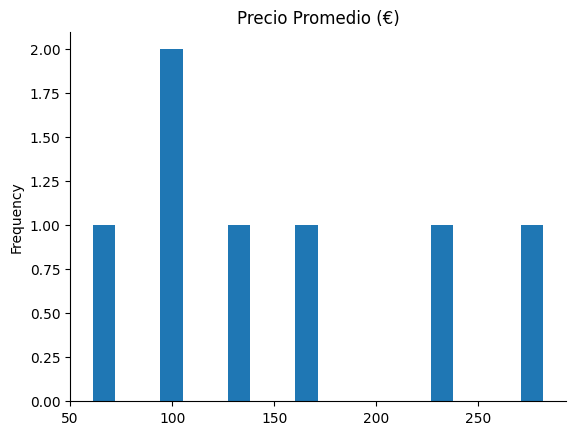

In [ ]:
# @title Precio Promedio (€)

from matplotlib import pyplot as plt
price_table_data['Precio Promedio (€)'].plot(kind='hist', bins=20, title='Precio Promedio (€)')
plt.gca().spines[['top', 'right',]].set_visible(False)

/tmp/ipython-input-82-1379467179.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




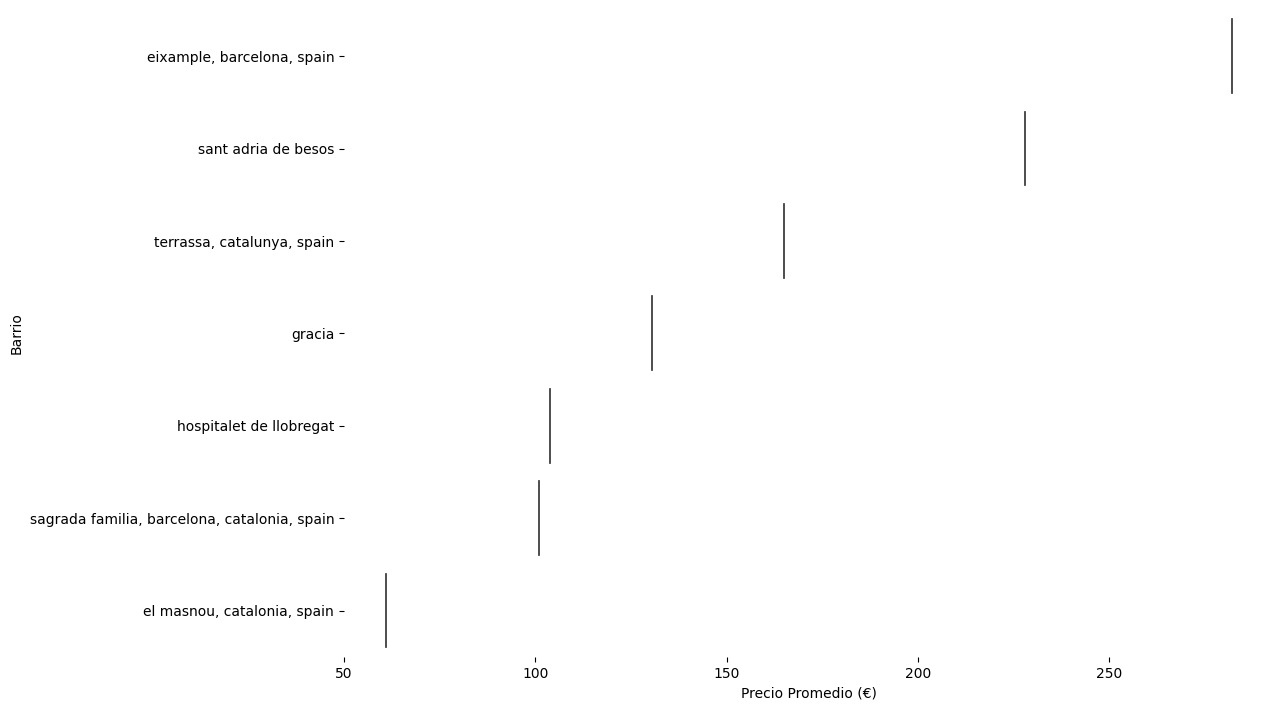

In [ ]:
# @title Barrio vs Precio Promedio (€)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(price_table_data['Barrio'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(price_table_data, x='Precio Promedio (€)', y='Barrio', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<Figure size 800x600 with 0 Axes>

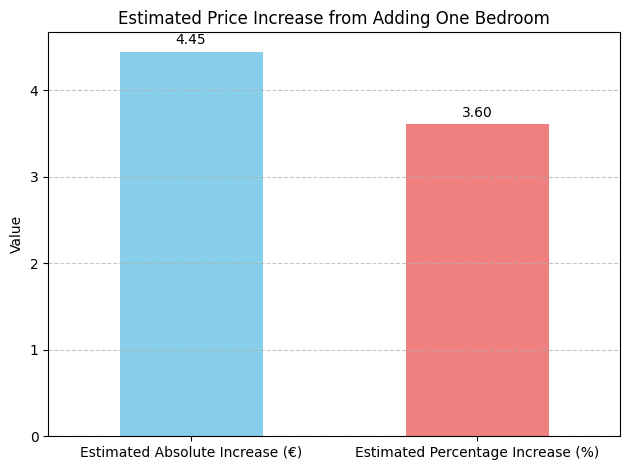


Estimated absolute increase in price by adding one bedroom: ≈ 4.45€
Estimated percentage increase in price by adding one bedroom: ≈ 3.60%


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure the required variables are available from previous executions
# aumento_estimado_bedrooms was calculated in cell 'bb033a9b'
# precio_referencia was calculated in cell 'bb033a9b' and 'f29804eb'

if 'aumento_estimado_bedrooms' in locals() and 'precio_referencia' in locals():
    # Calculate the estimated percentage increase
    # The estimated absolute increase is aumento_estimado_bedrooms
    # The base price is precio_referencia
    estimated_percentage_increase_bedrooms = (aumento_estimado_bedrooms / precio_referencia) * 100

    # Create data for the bar chart
    comparison_data = {
        'Metric': ['Estimated Absolute Increase (€)', 'Estimated Percentage Increase (%)'],
        'Value': [aumento_estimado_bedrooms, estimated_percentage_increase_bedrooms]
    }
    df_comparison = pd.DataFrame(comparison_data)

    # Create the bar chart
    plt.figure(figsize=(8, 6))
    ax = df_comparison.plot(kind='bar', x='Metric', y='Value', legend=False, color=['skyblue', 'lightcoral'])

    # Add labels to the bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

    plt.title("Estimated Price Increase from Adding One Bedroom")
    plt.ylabel("Value")
    plt.xlabel("") # Remove x-axis label as metric names are the labels
    plt.xticks(rotation=0) # Keep labels horizontal
    plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid lines on Y-axis
    plt.tight_layout()
    plt.show()

    print(f"\nEstimated absolute increase in price by adding one bedroom: ≈ {aumento_estimado_bedrooms:.2f}€")
    print(f"Estimated percentage increase in price by adding one bedroom: ≈ {estimated_percentage_increase_bedrooms:.2f}%")

else:
    print("Error: Necessary variables (aumento_estimado_bedrooms or precio_referencia) are not available.")
    print("Please ensure the cells that calculate the OLS model and the estimated impacts were run successfully.")

<Figure size 800x600 with 0 Axes>

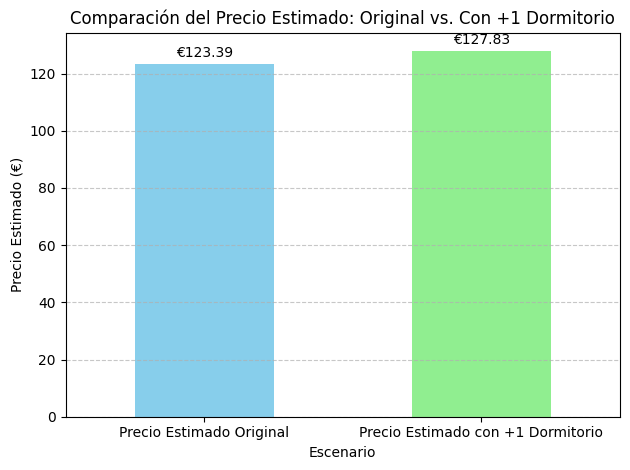


Precio estimado original (promedio de referencia): ≈ 123.39€
Precio estimado con un dormitorio adicional: ≈ 127.83€
Aumento estimado absoluto: ≈ 4.45€


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Assuming 'price_referencia' (original estimated price) and 'price_accommodates_plus_1'
# (estimated price with +1 accommodates) are available from previous cells.
# In this case, we want to compare the price with +1 bedroom, not accommodates.
# The variable 'aumento_estimado_bedrooms' was calculated in cell 'bb033a9b'
# and the 'precio_referencia' was also used there and in cell 'f29804eb'.

if 'aumento_estimado_bedrooms' in locals() and 'precio_referencia' in locals():
    # Calculate the estimated price after adding one bedroom
    # Estimated price = Original reference price + Estimated increase from adding one bedroom
    estimated_price_with_bedroom = precio_referencia + aumento_estimado_bedrooms

    # Create data for the bar chart
    comparison_data_bedrooms = {
        'Scenario': ['Precio Estimado Original', 'Precio Estimado con +1 Dormitorio'],
        'Precio (€)': [precio_referencia, estimated_price_with_bedroom]
    }
    df_comparison_bedrooms = pd.DataFrame(comparison_data_bedrooms)

    # Create the bar chart
    plt.figure(figsize=(8, 6))
    ax = df_comparison_bedrooms.plot(kind='bar', x='Scenario', y='Precio (€)', legend=False, color=['skyblue', 'lightgreen'])

    # Add labels to the bars with Euro symbol
    for container in ax.containers:
        ax.bar_label(container, fmt='€%.2f', label_type='edge', padding=3)

    plt.title("Comparación del Precio Estimado: Original vs. Con +1 Dormitorio")
    plt.ylabel("Precio Estimado (€)")
    plt.xlabel("Escenario")
    plt.xticks(rotation=0) # Keep labels horizontal
    plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid lines on Y-axis
    plt.tight_layout()
    plt.show()

    print(f"\nPrecio estimado original (promedio de referencia): ≈ {precio_referencia:.2f}€")
    print(f"Precio estimado con un dormitorio adicional: ≈ {estimated_price_with_bedroom:.2f}€")
    print(f"Aumento estimado absoluto: ≈ {aumento_estimado_bedrooms:.2f}€")

else:
    print("Error: Las variables necesarias (aumento_estimado_bedrooms o precio_referencia) no están disponibles.")
    print("Por favor, asegúrate de ejecutar las celdas que calculan el modelo OLS y los impactos estimados.")

In [ ]:
# Calculate the average number of people a listing accommodates
average_accommodates = listings['accommodates'].mean()

# Print the average in a formatted way suitable for a dashboard card
print(f"Average Accommodates: {average_accommodates:.2f}")

Average Accommodates: 3.37


### Average Accommodates

**{average_accommodates:.2f}**

*Average number of people a listing can accommodate.*

In [ ]:
import numpy as np

# Assuming 'aumento_estimado_accommodates' and 'precio_referencia' are available from previous cells.
# 'aumento_estimado_accommodates' was calculated in cell 'f29804eb'
# 'precio_referencia' was calculated in cell 'bb033a9b' and 'f29804eb'

if 'aumento_estimado_accommodates' in locals() and 'precio_referencia' in locals():
    # Calculate the estimated percentage increase
    estimated_percentage_increase_accommodates = (aumento_estimado_accommodates / precio_referencia) * 100

    # Print the percentage increase in a formatted way suitable for a dashboard card
    print(f"Estimated Percentage Impact of Accommodates on Price: {estimated_percentage_increase_accommodates:.2f}%")

else:
    print("Error: Necessary variables (aumento_estimado_accommodates or precio_referencia) are not available.")
    print("Please ensure the cells that calculate the OLS model and the estimated impacts were run successfully.")

Estimated Percentage Impact of Accommodates on Price: 14.47%


### Estimated Price Increase per Accommodates

**{estimated_percentage_increase_accommodates:.2f}%**

*Estimated percentage increase in price for each additional person a listing accommodates (based on linear model).*

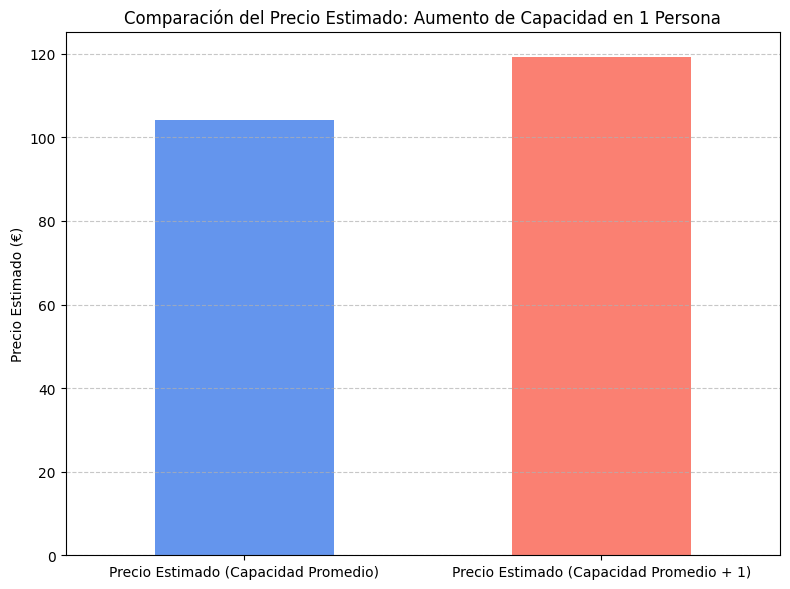

Estimación del aumento absoluto en el precio al añadir una persona a la capacidad: ≈ 15.21€


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Assuming modelo_sm and X_sm are available from the OLS model training cell

if 'modelo_sm' not in locals() or 'X_sm' not in locals():
    print("Error: El modelo de regresión lineal (modelo_sm) o los datos (X_sm) no están disponibles.")
    print("Por favor, ejecuta la celda donde se entrena el modelo OLS.")
else:
    # 1. Crear un punto de referencia (por ejemplo, usando los valores promedio de las características)
    X_sm_features = X_sm.drop(columns='const') if 'const' in X_sm.columns else X_sm
    punto_referencia = X_sm_features.mean()

    # 2. Crear dos escenarios para la predicción:
    # Escenario 1: Precio estimado en el punto de referencia (capacidad promedio)
    # Usamos el punto de referencia tal cual para esta predicción.
    punto_referencia_df = pd.DataFrame([punto_referencia], columns=X_sm_features.columns)
    if 'const' in X_sm.columns:
        punto_referencia_df = sm.add_constant(punto_referencia_df, has_constant='add')
    punto_referencia_df = punto_referencia_df[X_sm.columns] # Ensure order

    # Escenario 2: Precio estimado con capacidad + 1
    punto_referencia_accommodates_plus_1 = punto_referencia.copy()
    # Asegurarse de que 'accommodates' es numérico antes de sumar
    punto_referencia_accommodates_plus_1['accommodates'] = pd.to_numeric(punto_referencia_accommodates_plus_1['accommodates'], errors='coerce')
    if pd.notnull(punto_referencia_accommodates_plus_1['accommodates']):
         punto_referencia_accommodates_plus_1['accommodates'] += 1
    else:
        # Handle case where accommodates was NaN even in the mean (unlikely after dropna)
        punto_referencia_accommodates_plus_1['accommodates'] = 1 # or some default value

    punto_referencia_accommodates_plus_1_df = pd.DataFrame([punto_referencia_accommodates_plus_1], columns=X_sm_features.columns)
    if 'const' in X_sm.columns:
        punto_referencia_accommodates_plus_1_df = sm.add_constant(punto_referencia_accommodates_plus_1_df, has_constant='add')
    punto_referencia_accommodates_plus_1_df = punto_referencia_accommodates_plus_1_df[X_sm.columns] # Ensure order


    # 3. Predecir el log_price para ambos escenarios
    log_price_referencia = modelo_sm.predict(punto_referencia_df)[0]
    log_price_accommodates_plus_1 = modelo_sm.predict(punto_referencia_accommodates_plus_1_df)[0]

    # 4. Convertir el log_price predicho a la escala original del precio
    price_referencia = np.expm1(log_price_referencia)
    price_accommodates_plus_1 = np.expm1(log_price_accommodates_plus_1)

    # 5. Crear los datos para el gráfico de barras
    precios_estimados = pd.Series({
        "Precio Estimado (Capacidad Promedio)": price_referencia,
        "Precio Estimado (Capacidad Promedio + 1)": price_accommodates_plus_1
    })

    # 6. Crear el gráfico de barras
    plt.figure(figsize=(8, 6))
    precios_estimados.plot(kind='bar', color=['cornflowerblue', 'salmon'])
    plt.title("Comparación del Precio Estimado: Aumento de Capacidad en 1 Persona")
    plt.ylabel("Precio Estimado (€)")
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Mostrar el aumento estimado también
    aumento_estimado = price_accommodates_plus_1 - price_referencia
    print(f"Estimación del aumento absoluto en el precio al añadir una persona a la capacidad: ≈ {aumento_estimado:.2f}€")

In [ ]:
print("Columnas usadas en el modelo OLS:")
print(X_sm.columns.tolist())


Columnas usadas en el modelo OLS:
['const', 'accommodates', 'bathrooms', 'bedrooms', 'log_minimum_nights_avg_ntm', 'number_of_reviews', 'estimated_occupancy_l365d', 'reviews_per_month', 'kw_tv', 'kw_coffee maker', 'kw_refrigerator', 'kw_host greets you', 'kw_travel crib', 'kw_iron', 'kw_city skyline view', 'kw_sea view', 'kw_parking', 'kw_wifi', 'kw_dishes and silverware', 'kw_elevator', 'kw_hair dryer', 'kw_ac', 'kw_washing machine', 'kw_beach', 'kw_cot', 'kw_cleaning', 'kw_shampoo', 'kw_essentials', 'kw_dishes', 'kw_silverware', 'kw_kitchen', 'kw_heating', 'kw_air conditioning', 'kw_cooking basics', 'kw_washer', 'kw_bed linens', 'neighbourhood_group_cleansed_Eixample', 'neighbourhood_group_cleansed_Gràcia', 'neighbourhood_group_cleansed_Horta-Guinardó', 'neighbourhood_group_cleansed_Les Corts', 'neighbourhood_group_cleansed_Nou Barris', 'neighbourhood_group_cleansed_Sant Andreu', 'neighbourhood_group_cleansed_Sant Martí', 'neighbourhood_group_cleansed_Sants-Montjuïc', 'neighbourhood_

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Ensure modelo_sm and X_sm are available from the OLS model training cell
if 'modelo_sm' not in locals() or 'X_sm' not in locals():
    print("Error: El modelo de regresión lineal (modelo_sm) o los datos (X_sm) no están disponibles.")
    print("Por favor, ejecuta la celda donde se entrena el modelo OLS antes de ejecutar esta celda.")
else:
    # 1. Crear un punto de referencia (usando los valores promedio de las características)
    # Excluir la constante 'const' si existe en X_sm para el cálculo del promedio
    X_sm_features = X_sm.drop(columns='const') if 'const' in X_sm.columns else X_sm
    punto_referencia = X_sm_features.mean()

    # Add the constant term back for prediction
    punto_referencia_df = pd.DataFrame([punto_referencia], columns=X_sm_features.columns)
    if 'const' in X_sm.columns:
        punto_referencia_df = sm.add_constant(punto_referencia_df, has_constant='add')
    punto_referencia_df = punto_referencia_df[X_sm.columns] # Ensure order matches X_sm

    # Predict the base log_price for the reference point
    base_log_price = modelo_sm.predict(punto_referencia_df)[0]
    base_price = np.expm1(base_log_price)

    print(f"Precio base estimado (promedio de referencia): ≈ {base_price:.2f}€")


    # 2. Escenario 1: Disminuir 'log_minimum_nights_avg_ntm' en 1 punto (unidad logarítmica)
    # Create a copy of the reference point for this scenario
    punto_referencia_min_nights_down = punto_referencia.copy()

    # Ensure 'log_minimum_nights_avg_ntm' is in the features and is numeric
    if 'log_minimum_nights_avg_ntm' in punto_referencia_min_nights_down.index:
         punto_referencia_min_nights_down['log_minimum_nights_avg_ntm'] -= 1
    else:
        print("Advertencia: 'log_minimum_nights_avg_ntm' no se encuentra en las características del modelo.")


    # Prepare the data point for prediction
    punto_referencia_min_nights_down_df = pd.DataFrame([punto_referencia_min_nights_down], columns=X_sm_features.columns)
    if 'const' in X_sm.columns:
        punto_referencia_min_nights_down_df = sm.add_constant(punto_referencia_min_nights_down_df, has_constant='add')
    punto_referencia_min_nights_down_df = punto_referencia_min_nights_down_df[X_sm.columns] # Ensure order

    # Predict the log_price for Scenario 1
    log_price_min_nights_down = modelo_sm.predict(punto_referencia_min_nights_down_df)[0]
    price_min_nights_down = np.expm1(log_price_min_nights_down)

    print(f"Precio estimado con 'log_minimum_nights_avg_ntm' -1: ≈ {price_min_nights_down:.2f}€")


    # 3. Escenario 2: Agregar amenities específicos
    amenidades_a_agregar_simulacion = [
        "kw_hair dryer",
        "kw_ac",
        "kw_host greets you",
        "kw_heating",
        "kw_washer",
        "kw_bed linens"
    ]

    # Create a copy of the reference point for this scenario
    punto_referencia_amenities_added = punto_referencia.copy()

    # Set the specified amenity features to 1 (assuming they were 0 in the average/reference point)
    # Check if the amenity column exists in the model features before setting
    print("\nConfigurando amenities para la simulación:")
    for amenidad in amenidades_a_agregar_simulacion:
        if amenidad in punto_referencia_amenities_added.index:
            punto_referencia_amenities_added[amenidad] = 1
            print(f"- {amenidad}: configurado a 1")
        else:
            print(f"- Advertencia: La amenidad '{amenidad}' no se encuentra en las características del modelo. No se modificará.")


    # Prepare the data point for prediction
    punto_referencia_amenities_added_df = pd.DataFrame([punto_referencia_amenities_added], columns=X_sm_features.columns)
    if 'const' in X_sm.columns:
        punto_referencia_amenities_added_df = sm.add_constant(punto_referencia_amenities_added_df, has_constant='add')
    punto_referencia_amenities_added_df = punto_referencia_amenities_added_df[X_sm.columns] # Ensure order


    # Predict the log_price for Scenario 2
    log_price_amenities_added = modelo_sm.predict(punto_referencia_amenities_added_df)[0]
    price_amenities_added = np.expm1(log_price_amenities_added)

    print(f"\nPrecio estimado con amenities agregados: ≈ {price_amenities_added:.2f}€")


    # 4. Crear un DataFrame para comparar los resultados
    comparacion_precios = pd.DataFrame({
        "Escenario": ["Precio Base Estimado", "Precio Estimado (-1 log_min_nights)", "Precio Estimado (+Amenities)"],
        "Precio Estimado (€)": [base_price, price_min_nights_down, price_amenities_added]
    })

    # Add columns for absolute and percentage increase relative to the base price
    comparacion_precios["Aumento Absoluto (€)"] = comparacion_precios["Precio Estimado (€)"] - base_price
    # Handle division by zero if base_price is 0 or very close
    comparacion_precios["Aumento Porcentual (%)"] = (comparacion_precios["Aumento Absoluto (€)"] / base_price * 100).replace([np.inf, -np.inf], np.nan).fillna(0)

    # Optionally, add columns showing the specific change made for clarity
    comparacion_precios["Cambio Simulado"] = ["Base", "-1 log_min_nights_avg_ntm", "+ amenities: " + ", ".join([amenidad.replace("kw_", "") for amenidad in amenidades_a_agregar_simulacion if amenidad in X_sm.columns])]


    # Mostrar el DataFrame
    print("\nTabla Comparativa de Precios Estimados:")
    display(comparacion_precios)

    # 5. Preparar para exportar a Excel
    excel_filename = "estimacion_precios_simulacion.xlsx"
    comparacion_precios.to_excel(excel_filename, index=False)

    print(f"\n✅ Datos exportados a '{excel_filename}' listos para importar a Tableau.")

Precio base estimado (promedio de referencia): ≈ 104.08€
Precio estimado con 'log_minimum_nights_avg_ntm' -1: ≈ 124.27€

Configurando amenities para la simulación:
- kw_hair dryer: configurado a 1
- kw_ac: configurado a 1
- kw_host greets you: configurado a 1
- kw_heating: configurado a 1
- kw_washer: configurado a 1
- kw_bed linens: configurado a 1

Precio estimado con amenities agregados: ≈ 103.32€

Tabla Comparativa de Precios Estimados:


,Escenario,Precio Estimado (€),Aumento Absoluto (€),Aumento Porcentual (%),Cambio Simulado
0,Precio Base Estimado,104.084076,0.000000,0.000000,Base
1,Precio Estimado (-1 log_min_nights),124.271276,20.187200,19.395090,-1 log_min_nights_avg_ntm
2,Precio Estimado (+Amenities),103.321963,-0.762112,-0.732209,"+ amenities: hair dryer, ac, host greets you, ..."



✅ Datos exportados a 'estimacion_precios_simulacion.xlsx' listos para importar a Tableau.


In [ ]:
# Puedes definir el id ficticio del punto de referencia si no viene de un listing real
id_referencia = "Simulado"

# Añadir columnas
comparacion_precios["id"] = id_referencia
comparacion_precios["price_original"] = base_price

# Reordenar columnas si deseas mejor presentación en Tableau
columnas_finales = [
    "id", "Escenario", "Cambio Simulado",
    "price_original", "Precio Estimado (€)", "Aumento Absoluto (€)", "Aumento Porcentual (%)"
]
comparacion_precios = comparacion_precios[columnas_finales]

# Exportar a Excel
excel_filename = "estimacion_precios_simulacion_con_id_price.xlsx"
comparacion_precios.to_excel(excel_filename, index=False)

print(f"\n✅ Archivo actualizado exportado a '{excel_filename}' con columnas 'id' y 'price_original' listo para Tableau.")



✅ Archivo actualizado exportado a 'estimacion_precios_simulacion_con_id_price.xlsx' con columnas 'id' y 'price_original' listo para Tableau.


In [ ]:
import pandas as pd
import numpy as np

# ================================
# 1. Crear copia del DataFrame original
# ================================
df_prediccion = X.copy()
df_prediccion["id"] = df["id"]
df_prediccion["price_original"] = y  # y es el precio original (target)

# ================================
# 2. Simular aumento de 1 punto en review_scores_rating
# ================================
if "review_scores_rating" in df_prediccion.columns:
    df_prediccion["review_scores_rating_simulado"] = df_prediccion["review_scores_rating"] + 1
else:
    raise ValueError("La columna 'review_scores_rating' no está en X.")

# ================================
# 3. Crear nuevo conjunto de predicción con el cambio aplicado
# ================================
X_simulado = df_prediccion.copy()
X_simulado["review_scores_rating"] = X_simulado["review_scores_rating_simulado"]
X_simulado = X_simulado[X.columns]  # Asegurar orden y columnas iguales

# ================================
# 4. Predecir nuevo precio con el modelo Random Forest
# ================================
precio_estimado = modelo_mejorado.predict(X_simulado)
df_prediccion["precio_estimado"] = precio_estimado.round(2)

# ================================
# 5. Calcular aumento absoluto y porcentual
# ================================
df_prediccion["aumento_absoluto"] = (df_prediccion["precio_estimado"] - df_prediccion["price_original"]).round(2)
df_prediccion["aumento_porcentual"] = ((df_prediccion["aumento_absoluto"] / df_prediccion["price_original"]) * 100).round(2)

# ================================
# 6. Exportar solo columnas clave
# ================================
columnas_finales = ["id", "price_original", "precio_estimado", "aumento_absoluto", "aumento_porcentual"]
df_prediccion[columnas_finales].to_excel("prediccion_aumento_por_review_score.xlsx", index=False)

print("✅ Archivo exportado: prediccion_aumento_por_review_score.xlsx")


KeyError: 'id'

In [ ]:
import pandas as pd
import numpy as np

# ================================
# 1. Preparar el DataFrame base
# ================================
df_prediccion = listings_filtrado.copy()

# Asegurarse de que las columnas necesarias existen
if "review_scores_rating" not in df_prediccion.columns or "price" not in df_prediccion.columns or "id" not in df_prediccion.columns:
    raise ValueError("Faltan columnas necesarias en listings_filtrado: 'review_scores_rating', 'price' o 'id'.")

# Renombrar 'price' como 'price_original' para claridad
df_prediccion["price_original"] = df_prediccion["price"]

# ================================
# 2. Simular aumento de 1 punto en review score
# ================================
df_prediccion["review_scores_rating_simulado"] = df_prediccion["review_scores_rating"] + 1

# ================================
# 3. Crear conjunto de predicción
# ================================
X_simulado = df_prediccion.copy()
X_simulado["review_scores_rating"] = X_simulado["review_scores_rating_simulado"]

# Asegurar que las columnas coinciden con las del modelo
X_simulado = X_simulado[X.columns]  # Usa las mismas columnas que se usaron para entrenar el modelo

# ================================
# 4. Predecir nuevo precio
# ================================
precio_estimado = modelo_mejorado.predict(X_simulado)
df_prediccion["precio_estimado"] = precio_estimado.round(2)

# ================================
# 5. Calcular aumento absoluto y porcentual
# ================================
df_prediccion["aumento_absoluto"] = (df_prediccion["precio_estimado"] - df_prediccion["price_original"]).round(2)
df_prediccion["aumento_porcentual"] = ((df_prediccion["aumento_absoluto"] / df_prediccion["price_original"]) * 100).round(2)

# ================================
# 6. Exportar columnas clave
# ================================
columnas_finales = ["id", "price_original", "precio_estimado", "aumento_absoluto", "aumento_porcentual"]
df_prediccion[columnas_finales].to_excel("prediccion_review_score_listings_filtrado.xlsx", index=False)

print("✅ Archivo exportado: prediccion_review_score_listings_filtrado.xlsx")


ValueError: Faltan columnas necesarias en listings_filtrado: 'review_scores_rating', 'price' o 'id'.

In [ ]:
import pandas as pd
import numpy as np

# ================================
# 1. Preparar el DataFrame base
# ================================
df_prediccion = listings.copy()

# Verificar columnas necesarias
if "review_scores_rating" not in df_prediccion.columns or "price" not in df_prediccion.columns or "id" not in df_prediccion.columns:
    raise ValueError("Faltan columnas necesarias en listings: 'review_scores_rating', 'price' o 'id'.")

# Renombrar 'price' como 'price_original'
df_prediccion["price_original"] = df_prediccion["price"]

# ================================
# 2. Simular aumento de 1 punto en review score
# ================================
df_prediccion["review_scores_rating_simulado"] = df_prediccion["review_scores_rating"] + 1

# ================================
# 3. Crear conjunto de predicción
# ================================
X_simulado = df_prediccion.copy()
X_simulado["review_scores_rating"] = X_simulado["review_scores_rating_simulado"]

# Asegurar que las columnas coinciden con las del modelo
X_simulado = X_simulado[X.columns]  # Usa las mismas columnas que se usaron para entrenar el modelo

# ================================
# 4. Predecir nuevo precio
# ================================
precio_estimado = modelo_mejorado.predict(X_simulado)
df_prediccion["precio_estimado"] = precio_estimado.round(2)

# ================================
# 5. Calcular aumento absoluto y porcentual
# ================================
df_prediccion["aumento_absoluto"] = (df_prediccion["precio_estimado"] - df_prediccion["price_original"]).round(2)
df_prediccion["aumento_porcentual"] = ((df_prediccion["aumento_absoluto"] / df_prediccion["price_original"]) * 100).round(2)

# ================================
# 6. Exportar columnas clave
# ================================
columnas_finales = ["id", "price_original", "precio_estimado", "aumento_absoluto", "aumento_porcentual"]
df_prediccion[columnas_finales].to_excel("prediccion_review_score_listings.xlsx", index=False)

print("✅ Archivo exportado: prediccion_review_score_listings.xlsx")


KeyError: "['neighbourhood_group_Ciutat Vella', 'neighbourhood_group_Eixample', 'neighbourhood_group_Gràcia', 'neighbourhood_group_Horta-Guinardó', 'neighbourhood_group_Les Corts', 'neighbourhood_group_Nou Barris', 'neighbourhood_group_Sant Andreu', 'neighbourhood_group_Sant Martí', 'neighbourhood_group_Sants-Montjuïc', 'neighbourhood_group_Sarrià-Sant Gervasi'] not in index"